# iNaturalist: 30 experimentos, código completo
Jeanpier Garay · Diego Pacheco · Jesus Castillo

Ejecutar de arriba abajo. `MODE='audit'` reproduce métricas publicadas;
`MODE='train'` prepara el corpus y entrena **los 30**; `MODE='smoke'` prueba
la implementación con tensores sintéticos. El código está visible en las celdas.
Entrenar requiere CUDA/BF16, espacio para datos/caché/checkpoints y tiempo de GPU.
Una repetición usa las mismas recetas; la política CUDA original no garantiza
igualdad bit a bit. Entrega final del proyecto, aprobada para su publicación.


In [1]:
import os, sys, subprocess, json, hashlib, math, random, time, gc
from pathlib import Path
from dataclasses import asdict, dataclass, field
from collections import Counter, defaultdict

MODE = os.environ.get("INAT_MODE", "audit")  # audit | train | smoke
INSTALL_DEPENDENCIES = os.environ.get("INAT_INSTALL", "1") == "1"
assert (3, 10) <= sys.version_info[:2] < (3, 13), "Usar Python 3.10–3.12 (recomendado 3.12)."
WORKSPACE = Path(os.environ.get("INAT_WORKSPACE", Path.cwd() / "inat_reproducible")).resolve()
DATA_ROOT = Path(os.environ.get("INAT_DATA", WORKSPACE / "data")).resolve()
CACHE = Path(os.environ.get("INAT_CACHE", DATA_ROOT / "cache_144")).resolve()
RUN_ID = os.environ.get("INAT_RUN_ID", "reentrenamiento_30_v1")
RESULTADOS = WORKSPACE / "runs" / RUN_ID
REFERENCIAS = WORKSPACE / "publicados"
DEVICE = os.environ.get("INAT_DEVICE", "cuda")
WORKERS = 0 if os.name == "nt" else min(12, os.cpu_count() or 1)
PREP_WORKERS = min(16, os.cpu_count() or 1)
DETERMINISTIC = os.environ.get("INAT_DETERMINISTIC", "0") == "1"
RES_ALMACEN, RES_ENTRADA, NUM_CLASES, SEMILLA = 144, 128, 10000, 42
assert MODE in {"audit", "train", "smoke"}
assert RUN_ID and all(c.isalnum() or c in "_-" for c in RUN_ID)
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
os.environ["TORCH_HOME"] = str(WORKSPACE / "weights")
WORKSPACE.mkdir(parents=True, exist_ok=True)

PACKAGES = ["numpy==1.26.4", "pandas==2.2.3", "matplotlib==3.9.2", "Pillow==11.0.0"]
if INSTALL_DEPENDENCIES:
    wheel = "cu124" if MODE == "train" else "cpu"
    # Reiniciar kernel al cambiar audit/smoke -> train: no mezclar bibliotecas cargadas.
    expected = {"torch": "2.6.0+" + wheel, "torchvision": "0.21.0+" + wheel,
                "numpy": "1.26.4", "pandas": "2.2.3", "matplotlib": "3.9.2", "PIL": "11.0.0"}
    for name, version in expected.items():
        if name in sys.modules and getattr(sys.modules[name], "__version__", None) != version:
            raise RuntimeError(f"{name} ya está cargado con otra versión: reiniciar el kernel y ejecutar desde el inicio.")
    index = "https://download.pytorch.org/whl/" + wheel
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch==2.6.0+" + wheel,
                           "torchvision==0.21.0+" + wheel, "--index-url", index])
    subprocess.check_call([sys.executable, "-m", "pip", "install", *PACKAGES])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL
from PIL import Image
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, BatchSampler, RandomSampler, SequentialSampler, WeightedRandomSampler
from torchvision.ops import roi_align
import torchvision
import torchvision.models as tvm
from IPython.display import display

if MODE == "train":
    if DEVICE != "cuda" or not torch.cuda.is_available() or not torch.cuda.is_bf16_supported():
        raise RuntimeError("El entrenamiento publicado requiere GPU CUDA con BF16; audit y smoke funcionan en CPU.")
print("Modo:", MODE, "| Python:", sys.version.split()[0], "| Torch:", torch.__version__)


Modo: audit | Python: 3.12.14 | Torch: 2.6.0+cpu


## 1. Configuraciones de los 30 experimentos


In [2]:
@dataclass
class Config:
    id: str
    descripcion: str = ""
    # modelo
    modelo: str = "resnet18"
    preentrenado: bool = False
    ajuste: str = "completo"          # congelado | parcial | completo
    bn: bool = True
    dropout: float = 0.0
    modelo_kw: dict = field(default_factory=dict)
    # datos
    datos: str = "completo"           # completo | longtail | lt_balanceado
    aumento: str = "basico"           # ninguno | basico | fuerte
    muestreo: str = "uniforme"        # uniforme | ponderado  (Weighted Sampling)
    # optimización
    optimizador: str = "sgdm"         # sgd | sgdm | adam | adamw
    lr: float = 0.1
    factor_lr_backbone: float = 1.0   # lr del backbone = lr * factor (fine-tuning)
    weight_decay: float = 5e-5
    batch: int = 256
    epocas: int = 16
    warmup: float = 1.0               # épocas de calentamiento lineal del lr
    clip: float = 5.0                 # norma máxima del gradiente
    # pérdida
    perdida: str = "ce"               # ce | ce_ponderada | logit_ajustado
    label_smoothing: float = 0.0
    # early stopping (sobre Top-1 de validación)
    paciencia: int = 4
    min_delta: float = 0.001          # mejora mínima de 0.1 puntos porcentuales
    semilla: int = 42
    muon_lr: float = 0.02


In [3]:
BASE = dict(modelo="resnet18", optimizador="sgdm", lr=0.1, weight_decay=5e-5,
            aumento="basico", epocas=16, batch=256)

TL = dict(BASE, modelo="resnet50", preentrenado=True, factor_lr_backbone=0.1)

EXPERIMENTOS = [
    # ---------------------------------------------------- Parte 2: MLP baseline
    Config("E01", "MLP 32px (baseline)", modelo="mlp", modelo_kw=dict(res=32, ocultas=(2048, 1024)),
           optimizador="adam", lr=1e-3, weight_decay=0.0, aumento="ninguno", batch=512, epocas=16),
    Config("E02", "MLP 64px (efecto de la resolución de entrada)", modelo="mlp",
           modelo_kw=dict(res=64, ocultas=(2048, 1024)),
           optimizador="adam", lr=1e-3, weight_decay=0.0, aumento="ninguno", batch=512, epocas=16),

    # ------------------------------------ Parte 3: arquitecturas CNN desde cero
    Config("E03", "ResNet-18 desde cero (receta base)", **BASE),
    Config("E04", "ResNet-50 desde cero", **dict(BASE, modelo="resnet50")),
    Config("E05", "EfficientNet-B0 desde cero", **dict(BASE, modelo="efficientnet_b0")),

    # ------------------------- Parte 4: optimizadores (ResNet-18, resto = E03)
    # E03 es SGD+momentum lr 0.1. Se barre el lr de SGDm y de Adam para medir
    # la sensibilidad al learning rate de cada optimizador.
    Config("E06", "SGD sin momentum, lr 0.1", **dict(BASE, optimizador="sgd")),
    Config("E07", "SGD+momentum, lr 0.02", **dict(BASE, lr=0.02)),
    Config("E08", "SGD+momentum, lr 0.5", **dict(BASE, lr=0.5)),
    Config("E09", "Adam, lr 1e-3", **dict(BASE, optimizador="adam", lr=1e-3)),
    Config("E10", "Adam, lr 1e-4", **dict(BASE, optimizador="adam", lr=1e-4)),
    Config("E11", "Adam, lr 1e-2", **dict(BASE, optimizador="adam", lr=1e-2)),
    Config("E12", "AdamW, lr 1e-3, wd 0.05 (desacoplado)", **dict(BASE, optimizador="adamw", lr=1e-3, weight_decay=0.05)),

    # ----------------- Parte 5: ablation study de regularización (ResNet-18 SGDm)
    # Se añade un componente cada vez. Early stopping activo en todos.
    Config("A1", "sin BN, sin dropout, sin aumento, sin wd",
           **dict(BASE, bn=False, dropout=0.0, aumento="ninguno", weight_decay=0.0)),
    Config("A2", "+ BatchNorm", **dict(BASE, dropout=0.0, aumento="ninguno", weight_decay=0.0)),
    Config("A3", "+ BN + Dropout 0.3", **dict(BASE, dropout=0.3, aumento="ninguno", weight_decay=0.0)),
    Config("A4", "+ BN + Dropout + aumento fuerte", **dict(BASE, dropout=0.3, aumento="fuerte", weight_decay=0.0)),
    Config("A5", "+ BN + Dropout + aumento fuerte + wd 5e-5",
           **dict(BASE, dropout=0.3, aumento="fuerte", weight_decay=5e-5)),
    Config("A6", "BN + aumento básico (sin dropout, sin wd)", **dict(BASE, aumento="basico", weight_decay=0.0)),

    # ------------------ Parte 6: Transfer Learning (ResNet-50 ImageNet, vs E04)
    Config("T1", "A: Feature Extraction (backbone congelado)", **dict(TL, ajuste="congelado")),
    Config("T2", "B: Partial Fine-Tuning (layer4 + cabeza)", **dict(TL, ajuste="parcial")),
    Config("T3", "C: Full Fine-Tuning", **dict(TL, ajuste="completo")),
    Config("T4", "C + aumento fuerte + label smoothing 0.1 (mejor modelo)",
           **dict(TL, ajuste="completo", aumento="fuerte", label_smoothing=0.1)),

    # --------------- Parte 7: Long-tail (receta de T3; ~125k imágenes de train)
    Config("L1", "balanceado, mismo nº de imágenes que el long-tail (control)", **dict(TL, datos="lt_balanceado")),
    Config("L2", "long-tail sin corrección", **dict(TL, datos="longtail")),
    Config("L3", "long-tail + Weighted Cross-Entropy (1/n)", **dict(TL, datos="longtail", perdida="ce_ponderada")),
    Config("L4", "long-tail + Logit Adjustment (tau=1)", **dict(TL, datos="longtail", perdida="logit_ajustado")),
    Config("L5", "long-tail + Weighted Sampling", **dict(TL, datos="longtail", muestreo="ponderado")),
]
# L1 está definido pero no tiene resultados publicados: no integra los 30.
PLAN = [c for c in EXPERIMENTOS if c.id != "L1"]
common = asdict(next(c for c in PLAN if c.id == "E09"))
common.update(modelo="convnext_tiny", modelo_kw={"stochastic_depth_prob": 0.1}, muon_lr=0.02)
descriptions = {"N01": "ConvNeXt-Tiny desde cero con Adam",
                "N02": "ConvNeXt-Tiny desde cero con Muon + Adam auxiliar",
                "N03": "ConvNeXt-Tiny ImageNet: fine-tuning completo con Adam",
                "N04": "ConvNeXt-Tiny ImageNet: fine-tuning completo con Muon + Adam auxiliar"}
for id_, pretrained, optimizer in [("N01", False, "adam"), ("N02", False, "muon"),
                                   ("N03", True, "adam"), ("N04", True, "muon")]:
    spec = dict(common, id=id_, descripcion=descriptions[id_], preentrenado=pretrained,
                optimizador=optimizer, factor_lr_backbone=0.1 if pretrained else 1.0)
    PLAN.append(Config(**spec))
ALL_IDS = [c.id for c in PLAN]
SELECTED_IDS = os.environ.get("INAT_EXPERIMENTS", ",".join(ALL_IDS)).split(",")
assert len(PLAN) == 30 and len(set(ALL_IDS)) == 30
assert len(set(SELECTED_IDS)) == len(SELECTED_IDS) and set(SELECTED_IDS) <= set(ALL_IDS)
with pd.option_context("display.max_columns", None, "display.max_rows", None):
    display(pd.DataFrame([asdict(c) for c in PLAN])[["id", "modelo", "preentrenado", "ajuste", "optimizador",
           "lr", "factor_lr_backbone", "weight_decay", "batch", "epocas", "datos", "perdida", "aumento"]])


,id,modelo,preentrenado,ajuste,optimizador,lr,factor_lr_backbone,weight_decay,batch,epocas,datos,perdida,aumento
0,E01,mlp,False,completo,adam,0.0010,1.0,0.00000,512,16,completo,ce,ninguno
1,E02,mlp,False,completo,adam,0.0010,1.0,0.00000,512,16,completo,ce,ninguno
2,E03,resnet18,False,completo,sgdm,0.1000,1.0,0.00005,256,16,completo,ce,basico
3,E04,resnet50,False,completo,sgdm,0.1000,1.0,0.00005,256,16,completo,ce,basico
4,E05,efficientnet_b0,False,completo,sgdm,0.1000,1.0,0.00005,256,16,completo,ce,basico
5,E06,resnet18,False,completo,sgd,0.1000,1.0,0.00005,256,16,completo,ce,basico
6,E07,resnet18,False,completo,sgdm,0.0200,1.0,0.00005,256,16,completo,ce,basico
7,E08,resnet18,False,completo,sgdm,0.5000,1.0,0.00005,256,16,completo,ce,basico
8,E09,resnet18,False,completo,adam,0.0010,1.0,0.00005,256,16,completo,ce,basico
9,E10,resnet18,False,completo,adam,0.0001,1.0,0.00005,256,16,completo,ce,basico


In [4]:
PUBLIC_COMMIT = 'bc8482312850d5bd6bbb62e527b5d0b281791e4d'
PUBLIC_URL = "https://raw.githubusercontent.com/Jeamipas/iNaturalist2021_U/" + PUBLIC_COMMIT
PUBLICADOS = [
    {'id': 'A1', 'directory': 'experimento-dp-khipu/resultados/A1', 'preds_sha256': 'f3d04b48fbe69c1f4b581364a6b6f3ace4cfd968e4e97179a90575a14dcfec5a', 'config': {'id': 'A1', 'descripcion': 'sin BN, sin dropout, sin aumento, sin wd', 'modelo': 'resnet18', 'preentrenado': False, 'ajuste': 'completo', 'bn': False, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'ninguno', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 1.0, 'weight_decay': 0.0, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'A2', 'directory': 'experimento-dp-khipu/resultados/A2', 'preds_sha256': '8b784ac248e70f18267257505c03c2d03aff54ef52eb48c4cd8efefccf83e824', 'config': {'id': 'A2', 'descripcion': '+ BatchNorm', 'modelo': 'resnet18', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'ninguno', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 1.0, 'weight_decay': 0.0, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'A3', 'directory': 'experimento-dp-khipu/resultados/A3', 'preds_sha256': 'bcb1d30778f8b6b8ad93791b17b4af6b06c0e97d44203511eb1a2cc959d33852', 'config': {'id': 'A3', 'descripcion': '+ BN + Dropout 0.3', 'modelo': 'resnet18', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.3, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'ninguno', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 1.0, 'weight_decay': 0.0, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'A4', 'directory': 'experimento-dp-khipu/resultados/A4', 'preds_sha256': '45e0ba313381bbd54bbc6e398795905cb00adf995370c704bc9cd4b47e5e40a7', 'config': {'id': 'A4', 'descripcion': '+ BN + Dropout + aumento fuerte', 'modelo': 'resnet18', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.3, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'fuerte', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 1.0, 'weight_decay': 0.0, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'A5', 'directory': 'experimento-dp-khipu/resultados/A5', 'preds_sha256': '95c7e3ee0152443cd9d6365694510674baa6f34a12f3149fcae0b15f529ee29f', 'config': {'id': 'A5', 'descripcion': '+ BN + Dropout + aumento fuerte + wd 5e-5', 'modelo': 'resnet18', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.3, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'fuerte', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 1.0, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'A6', 'directory': 'experimento-dp-khipu/resultados/A6', 'preds_sha256': 'e09a8949c7ab7e09d15d1ddfcafd3cddb33692107832956e9a0440fde58e169d', 'config': {'id': 'A6', 'descripcion': 'BN + aumento básico (sin dropout, sin wd)', 'modelo': 'resnet18', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 1.0, 'weight_decay': 0.0, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'E01', 'directory': 'experimento-dp-khipu/resultados/E01', 'preds_sha256': '4d1bf402bcca5c498d41616a522476674d9d64c687a7356e9f0f61b116b82cdf', 'config': {'id': 'E01', 'descripcion': 'MLP 32px (baseline)', 'modelo': 'mlp', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {'res': 32, 'ocultas': [2048, 1024]}, 'datos': 'completo', 'aumento': 'ninguno', 'muestreo': 'uniforme', 'optimizador': 'adam', 'lr': 0.001, 'factor_lr_backbone': 1.0, 'weight_decay': 0.0, 'batch': 512, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'E02', 'directory': 'experimento-dp-khipu/resultados/E02', 'preds_sha256': 'f6e91cbdcdec6424511b411335b981c68bdee7771d016b68231b685a1561c1fa', 'config': {'id': 'E02', 'descripcion': 'MLP 64px (efecto de la resolución de entrada)', 'modelo': 'mlp', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {'res': 64, 'ocultas': [2048, 1024]}, 'datos': 'completo', 'aumento': 'ninguno', 'muestreo': 'uniforme', 'optimizador': 'adam', 'lr': 0.001, 'factor_lr_backbone': 1.0, 'weight_decay': 0.0, 'batch': 512, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'E03', 'directory': 'experimento-dp-khipu/resultados/E03', 'preds_sha256': '2471ab4f450229847c24aa43ab5cf209628664c9ccb25a1781c3c3c24e02b070', 'config': {'id': 'E03', 'descripcion': 'ResNet-18 desde cero (receta base)', 'modelo': 'resnet18', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 1.0, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'E04', 'directory': 'experimento-dp-khipu/resultados/E04', 'preds_sha256': '76ce3e2aadcb78d0e74b8015a926753f03df39537bca5bfefde4496a3e0607ba', 'config': {'id': 'E04', 'descripcion': 'ResNet-50 desde cero', 'modelo': 'resnet50', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 1.0, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'E05', 'directory': 'experimento-dp-khipu/resultados/E05', 'preds_sha256': '3fd83b3ec36cf31504a55700c4edbd4070b62e94d93b22d83226635bd27483ee', 'config': {'id': 'E05', 'descripcion': 'EfficientNet-B0 desde cero', 'modelo': 'efficientnet_b0', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 1.0, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'E06', 'directory': 'experimento-dp-khipu/resultados/E06', 'preds_sha256': 'e436aac9016a07d389f54990fcf6eb0849d0d26ec10463bff688a6ee1c71a0ea', 'config': {'id': 'E06', 'descripcion': 'SGD sin momentum, lr 0.1', 'modelo': 'resnet18', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'sgd', 'lr': 0.1, 'factor_lr_backbone': 1.0, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'E07', 'directory': 'experimento-dp-khipu/resultados/E07', 'preds_sha256': '028e708491a714a191cc521a37ee9fae5a71336ed4f9d43c2345e6c70ff02930', 'config': {'id': 'E07', 'descripcion': 'SGD+momentum, lr 0.02', 'modelo': 'resnet18', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.02, 'factor_lr_backbone': 1.0, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'E08', 'directory': 'experimento-dp-khipu/resultados/E08', 'preds_sha256': 'eba80bb41ed530b1ddd768cc4cbf7e90ff407e21a9e963d5c0bcf3c8d0bdbfdc', 'config': {'id': 'E08', 'descripcion': 'SGD+momentum, lr 0.5', 'modelo': 'resnet18', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.5, 'factor_lr_backbone': 1.0, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'E09', 'directory': 'experimento-dp-khipu/resultados/E09', 'preds_sha256': 'dbb4defb59eaf528826b778795b6959855a94267a352d5dea263efd3ce9de296', 'config': {'id': 'E09', 'descripcion': 'Adam, lr 1e-3', 'modelo': 'resnet18', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'adam', 'lr': 0.001, 'factor_lr_backbone': 1.0, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'E10', 'directory': 'experimento-dp-khipu/resultados/E10', 'preds_sha256': '025c6835b6e45377eab056aa7ffa85f30033762d589bcb9a747901c074ba056e', 'config': {'id': 'E10', 'descripcion': 'Adam, lr 1e-4', 'modelo': 'resnet18', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'adam', 'lr': 0.0001, 'factor_lr_backbone': 1.0, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'E11', 'directory': 'experimento-dp-khipu/resultados/E11', 'preds_sha256': '8e09a9e93fd0b8c935c0d3a038696b5446ce586437d52c8bcf30021cc8fbe6cf', 'config': {'id': 'E11', 'descripcion': 'Adam, lr 1e-2', 'modelo': 'resnet18', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'adam', 'lr': 0.01, 'factor_lr_backbone': 1.0, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'E12', 'directory': 'experimento-dp-khipu/resultados/E12', 'preds_sha256': '8bd6436d7b41734675e64f4e2b709a75389c625087c86d9ae6b8ee18ca9d6dd4', 'config': {'id': 'E12', 'descripcion': 'AdamW, lr 1e-3, wd 0.05 (desacoplado)', 'modelo': 'resnet18', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'adamw', 'lr': 0.001, 'factor_lr_backbone': 1.0, 'weight_decay': 0.05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'L2', 'directory': 'experimento-dp-khipu/resultados/L2', 'preds_sha256': '9d3c0da31b1d39cd6a37febaeb3409291498572e831c3cd4fbb52ee9b641b196', 'config': {'id': 'L2', 'descripcion': 'long-tail sin corrección', 'modelo': 'resnet50', 'preentrenado': True, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'longtail', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 0.1, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'L3', 'directory': 'experimento-dp-khipu/resultados/L3', 'preds_sha256': '52220d52f23bbac45339083bd04635a9153a96341a83cd7fb1b16172cc33a6b9', 'config': {'id': 'L3', 'descripcion': 'long-tail + Weighted Cross-Entropy (1/n)', 'modelo': 'resnet50', 'preentrenado': True, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'longtail', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 0.1, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce_ponderada', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'L4', 'directory': 'experimento-dp-khipu/resultados/L4', 'preds_sha256': 'fa407c8840779f328c15e67b9a6d31b85ba6e77d660791a68ddb9c6e037f870a', 'config': {'id': 'L4', 'descripcion': 'long-tail + Logit Adjustment (tau=1)', 'modelo': 'resnet50', 'preentrenado': True, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'longtail', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 0.1, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'logit_ajustado', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'L5', 'directory': 'experimento-dp-khipu/resultados/L5', 'preds_sha256': 'dcd3d186736e8170d1da774e33de9947692973a9152c46dac3caff2950eb2a2e', 'config': {'id': 'L5', 'descripcion': 'long-tail + Weighted Sampling', 'modelo': 'resnet50', 'preentrenado': True, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'longtail', 'aumento': 'basico', 'muestreo': 'ponderado', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 0.1, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'T1', 'directory': 'experimento-dp-khipu/resultados/T1', 'preds_sha256': 'a77bda8d829fc6c3a55c08a093ab7dddd5cc8790541d4eed111b9a401f57e3bb', 'config': {'id': 'T1', 'descripcion': 'A: Feature Extraction (backbone congelado)', 'modelo': 'resnet50', 'preentrenado': True, 'ajuste': 'congelado', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 0.1, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'T2', 'directory': 'experimento-dp-khipu/resultados/T2', 'preds_sha256': '9f8bbf2298de2539d6f0df34781f456dd4cae70e7b6dce037fa2273b7e7d7e5a', 'config': {'id': 'T2', 'descripcion': 'B: Partial Fine-Tuning (layer4 + cabeza)', 'modelo': 'resnet50', 'preentrenado': True, 'ajuste': 'parcial', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 0.1, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'T3', 'directory': 'experimento-dp-khipu/resultados/T3', 'preds_sha256': '2861ccb093f63b7b026fa62465547f28339dfd123af0d76884eb5a1f1bb4a68c', 'config': {'id': 'T3', 'descripcion': 'C: Full Fine-Tuning', 'modelo': 'resnet50', 'preentrenado': True, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 0.1, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'T4', 'directory': 'experimento-dp-khipu/resultados/T4', 'preds_sha256': '32ba0ae0ff7865fb31dc711700fdc028088ffc63bcae9edf902f65382ddd0777', 'config': {'id': 'T4', 'descripcion': 'C + aumento fuerte + label smoothing 0.1 (mejor modelo)', 'modelo': 'resnet50', 'preentrenado': True, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {}, 'datos': 'completo', 'aumento': 'fuerte', 'muestreo': 'uniforme', 'optimizador': 'sgdm', 'lr': 0.1, 'factor_lr_backbone': 0.1, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.1, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42}},
    {'id': 'N01', 'directory': 'outputs/convnext4_adam_muon_v3/N01', 'preds_sha256': 'e9846e86ed39f0f0bda62cb8b990ae31cea5986e67ccf45d041e8ac227434cbf', 'config': {'id': 'N01', 'descripcion': 'ConvNeXt-Tiny desde cero con Adam', 'modelo': 'convnext_tiny', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {'stochastic_depth_prob': 0.1}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'adam', 'lr': 0.001, 'factor_lr_backbone': 1.0, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42, 'muon_lr': 0.02}},
    {'id': 'N02', 'directory': 'outputs/convnext4_adam_muon_v3/N02', 'preds_sha256': '0626536f366804f43514989ab2f01eb0371c7e109e3e913a93f869baca9adb8d', 'config': {'id': 'N02', 'descripcion': 'ConvNeXt-Tiny desde cero con Muon + Adam auxiliar', 'modelo': 'convnext_tiny', 'preentrenado': False, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {'stochastic_depth_prob': 0.1}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'muon', 'lr': 0.001, 'factor_lr_backbone': 1.0, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42, 'muon_lr': 0.02}},
    {'id': 'N03', 'directory': 'outputs/convnext4_adam_muon_v3/N03', 'preds_sha256': '21111b42838e171b983a76520256ec7f9fd4c8bdc61a39de4e9d54dfcb751c94', 'config': {'id': 'N03', 'descripcion': 'ConvNeXt-Tiny ImageNet: fine-tuning completo con Adam', 'modelo': 'convnext_tiny', 'preentrenado': True, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {'stochastic_depth_prob': 0.1}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'adam', 'lr': 0.001, 'factor_lr_backbone': 0.1, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42, 'muon_lr': 0.02}},
    {'id': 'N04', 'directory': 'outputs/convnext4_adam_muon_v3/N04', 'preds_sha256': '5343e5349f13c81dbd631382a7fc2bf369ae5b7a7ad109461937b788e8a12099', 'config': {'id': 'N04', 'descripcion': 'ConvNeXt-Tiny ImageNet: fine-tuning completo con Muon + Adam auxiliar', 'modelo': 'convnext_tiny', 'preentrenado': True, 'ajuste': 'completo', 'bn': True, 'dropout': 0.0, 'modelo_kw': {'stochastic_depth_prob': 0.1}, 'datos': 'completo', 'aumento': 'basico', 'muestreo': 'uniforme', 'optimizador': 'muon', 'lr': 0.001, 'factor_lr_backbone': 0.1, 'weight_decay': 5e-05, 'batch': 256, 'epocas': 16, 'warmup': 1.0, 'clip': 5.0, 'perdida': 'ce', 'label_smoothing': 0.0, 'paciencia': 4, 'min_delta': 0.001, 'semilla': 42, 'muon_lr': 0.02}},
]

for entry in PUBLICADOS:
    cfg = asdict(next(c for c in PLAN if c.id == entry["id"]))
    frozen = entry["config"]
    # La descripción no afecta la receta; JSON representa tuplas como listas.
    normalize = lambda d: json.loads(json.dumps({k: v for k, v in d.items() if k != "descripcion"}))
    assert normalize({k: cfg[k] for k in frozen}) == normalize(frozen), entry["id"]
print("30 recetas contrastadas con las configuraciones publicadas.")


30 recetas contrastadas con las configuraciones publicadas.


## 2. Descarga, integridad y preparación del corpus


In [5]:
def atomic_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(value, indent=2, ensure_ascii=False, allow_nan=False), encoding="utf-8")
    temporary.replace(path)

def digest(path, algorithm="sha256"):
    h = hashlib.new(algorithm)
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def read_split(data_root, split, expected_classes=10000, expected_per_class=None):
    root = Path(data_root).resolve()
    path = root / ("train_mini.json" if split == "train_mini" else "val.json")
    meta = json.loads(path.read_text(encoding="utf-8"))
    categories = {int(c["id"]): c for c in meta["categories"]}
    labels = {category: label for label, category in enumerate(sorted(categories))}
    image_map = {int(im["id"]): im for im in meta["images"]}
    if len(image_map) != len(meta["images"]):
        raise ValueError("Duplicate image IDs")
    annotation_map = {}
    for ann in meta["annotations"]:
        image_id = int(ann["image_id"])
        if image_id in annotation_map or image_id not in image_map:
            raise ValueError("Each image must have exactly one existing annotation")
        annotation_map[image_id] = int(ann["category_id"])
    if set(annotation_map) != set(image_map):
        raise ValueError("Unannotated images or unknown image IDs")
    entries = []
    for im in meta["images"]:
        name = im["file_name"].replace("\\", "/")
        relative = Path(name)
        if relative.is_absolute() or ".." in relative.parts or relative.parts[0] != split:
            raise ValueError(f"Invalid image path: {name}")
        cat = annotation_map[int(im["id"])]
        entries.append((name, labels[cat]))
    if len({name for name, _ in entries}) != len(entries):
        raise ValueError("Duplicate image paths")
    counts = Counter(label for _, label in entries)
    if len(categories) != expected_classes or len(counts) != expected_classes:
        raise ValueError(f"Expected {expected_classes} species, found {len(counts)}")
    if expected_per_class is not None and set(counts.values()) != {expected_per_class}:
        raise ValueError(f"Expected exactly {expected_per_class} images per species")
    return entries, categories, labels, meta

def audit_corpus(data_root, output=None, expected_classes=10000, train_per_class=50, val_per_class=10):
    root = Path(data_root)
    training, categories, labels, train_meta = read_split(root, "train_mini", expected_classes, train_per_class)
    validation, val_categories, val_labels, val_meta = read_split(root, "val", expected_classes, val_per_class)
    if labels != val_labels or categories != val_categories:
        raise ValueError("Training and validation taxonomy/mapping disagree")
    if {Path(p).name for p, _ in training} & {Path(p).name for p, _ in validation}:
        raise ValueError("Image filenames overlap across training and validation")
    grouped = defaultdict(set)
    for name, _ in training + validation:
        relative = Path(name)
        grouped[relative.parent].add(relative.name)
    missing = []
    for parent, expected in grouped.items():
        folder = root / parent
        available = {item.name for item in os.scandir(folder) if item.is_file()} if folder.is_dir() else set()
        missing.extend(str(parent / n) for n in expected - available)
    if missing:
        raise FileNotFoundError(f"{len(missing)} missing images; examples: {missing[:5]}")
    report = {
        "train_images": len(training), "val_images": len(validation), "species": len(labels),
        "train_per_species": train_per_class, "val_per_species": val_per_class,
        "missing_files": 0, "overlapping_filenames": 0,
        "train_json_sha256": digest(root / "train_mini.json"),
        "val_json_sha256": digest(root / "val.json"),
        "category_to_label": labels,
        "species_by_kingdom": dict(Counter(c.get("kingdom", "Unknown") for c in categories.values())),
        "species_by_supercategory": dict(Counter(c.get("supercategory", "Unknown") for c in categories.values())),
        "dimension_summary": {},
        "file_integrity_scope": "All paths checked; official archives verified by MD5 during preparation; sampled images decoded in EDA.",
    }
    for split, meta in [("train", train_meta), ("val", val_meta)]:
        dimensions = [(im.get("width"), im.get("height")) for im in meta["images"]]
        report["dimension_summary"][split] = {
            "images_with_dimensions": sum(w is not None and h is not None for w, h in dimensions),
            "min_width": min((w for w, _ in dimensions if w is not None), default=None),
            "max_width": max((w for w, _ in dimensions if w is not None), default=None),
            "min_height": min((h for _, h in dimensions if h is not None), default=None),
            "max_height": max((h for _, h in dimensions if h is not None), default=None),
        }
    if output:
        atomic_json(output, report)
    return report

from urllib.request import Request, urlopen
from urllib.error import HTTPError
import tarfile

SOURCE = "https://ml-inat-competition-datasets.s3.amazonaws.com/2021/"
ARCHIVES = {"train_mini.json.tar.gz": "395a35be3651d86dc3b0d365b8ea5f92",
            "val.json.tar.gz": "4d761e0f6a86cc63e8f7afc91f6a8f0b",
            "train_mini.tar.gz": "db6ed8330e634445efc8fec83ae81442",
            "val.tar.gz": "f6f6e0e242e3d4c9569ba56400938afc"}

def download_file(url, target, expected=None, algorithm="sha256"):
    target = Path(target)
    target.parent.mkdir(parents=True, exist_ok=True)
    if target.exists():
        if expected and digest(target, algorithm) != expected:
            raise ValueError(f"Checksum distinto: {target}")
        return target
    partial = target.with_suffix(target.suffix + ".part")
    if partial.exists() and expected and digest(partial, algorithm) == expected:
        partial.replace(target)
        return target
    for attempt in range(3):
        offset = partial.stat().st_size if partial.exists() else 0
        headers = {"User-Agent": "iNaturalist-reproducible-notebook"}
        if offset:
            headers["Range"] = f"bytes={offset}-"
        try:
            with urlopen(Request(url, headers=headers), timeout=60) as response:
                append = offset > 0 and response.status == 206
                with partial.open("ab" if append else "wb") as stream:
                    while chunk := response.read(8 * 1024 * 1024):
                        stream.write(chunk)
            if expected and digest(partial, algorithm) != expected:
                raise ValueError(f"Checksum de descarga distinto: {target}")
            partial.replace(target)
            return target
        except (OSError, HTTPError):
            if attempt == 2:
                raise
            time.sleep(2)

def prepare_full_data():
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    if all((DATA_ROOT / name).exists() for name in ("train_mini.json", "val.json", "train_mini", "val")):
        try:
            return audit_corpus(DATA_ROOT)
        except FileNotFoundError:
            pass
    for filename, checksum in ARCHIVES.items():
        archive = download_file(SOURCE + filename, DATA_ROOT / "archives" / filename, checksum, "md5")
        print("Extrayendo:", filename, flush=True)
        with tarfile.open(archive, "r|gz") as tar:
            for member in tar:
                destination = (DATA_ROOT / member.name).resolve()
                if member.issym() or member.islnk() or not destination.is_relative_to(DATA_ROOT):
                    raise ValueError("Ruta no válida en el archivo del dataset")
                tar.extract(member, DATA_ROOT, filter="data")
    return audit_corpus(DATA_ROOT)


In [6]:
TAXONOMIA = ["kingdom", "phylum", "class", "order", "family", "genus", "supercategory"]
def construir_indice(split):
    d = json.loads((DATA_ROOT / f"{split}.json").read_text())
    img = pd.DataFrame(d["images"])[["id", "file_name", "width", "height"]]
    ann = pd.DataFrame(d["annotations"])[["image_id", "category_id"]]
    cat = pd.DataFrame(d["categories"])
    cat["especie"] = cat["name"]
    df = img.merge(ann, left_on="id", right_on="image_id").merge(
        cat[["id", "especie", "common_name", *TAXONOMIA]].rename(columns={"id": "category_id"}),
        on="category_id",
    )
    df = df.rename(columns={"category_id": "etiqueta"}).drop(columns=["image_id"])
    # Orden estable (por etiqueta y nombre de archivo): la fila i del CSV es la
    # imagen i del memmap. No depende del orden del JSON.
    df = df.sort_values(["etiqueta", "file_name"]).reset_index(drop=True)
    assert df["etiqueta"].nunique() == 10_000
    return df

def construir_long_tail(df_train, n_max=50, n_min=1, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    C = df_train["etiqueta"].nunique()
    orden = rng.permutation(C)  # orden[r] = especie de rango r
    rango = np.empty(C, dtype=int)
    rango[orden] = np.arange(C)
    n_por_clase = np.floor(n_max * (n_min / n_max) ** (rango / (C - 1)) + 1e-9).astype(int)
    n_por_clase = np.clip(n_por_clase, n_min, n_max)

    idx_lt = []
    for c, grupo in df_train.groupby("etiqueta").groups.items():
        idx_lt.append(rng.choice(np.asarray(grupo), size=n_por_clase[c], replace=False))
    idx_lt = np.sort(np.concatenate(idx_lt))

    # Control: mismo número total de imágenes pero repartido por igual. Así
    # "balanceado vs long-tail" compara sólo la FORMA de la distribución y no
    # la cantidad de datos (el train completo tiene 4x más imágenes).
    k = int(round(len(idx_lt) / C))
    idx_bal = np.sort(np.concatenate([
        rng.choice(np.asarray(g), size=k, replace=False)
        for _, g in df_train.groupby("etiqueta").groups.items()
    ]))

    # Grupos de frecuencia (umbrales escalados de Liu et al. 2019, ImageNet-LT)
    grupo = np.where(n_por_clase >= 20, 0, np.where(n_por_clase >= 5, 1, 2))
    return dict(idx_lt=idx_lt, idx_bal=idx_bal, n_por_clase=n_por_clase, grupo=grupo,
                nombres_grupo=np.array(["frecuentes", "intermedias", "minoritarias"]))


In [7]:
%%writefile inat_resize_worker.py
from pathlib import Path
import numpy as np
from PIL import Image

def load_image(path, res=144):
    with Image.open(path) as original:
        original.draft("RGB", (res, res))
        im = original.convert("RGB")
    w, h = im.size
    scale = res / min(w, h)
    im = im.resize((max(res, round(w * scale)), max(res, round(h * scale))), Image.BICUBIC)
    w, h = im.size
    left, top = (w - res) // 2, (h - res) // 2
    return np.asarray(im.crop((left, top, left + res, top + res)))

def resize_block(task):
    data_root, memmap_path, n, start, filenames, res = task
    mm = np.memmap(memmap_path, dtype=np.uint8, mode="r+", shape=(n, res, res, 3))
    for offset, name in enumerate(filenames):
        mm[start + offset] = load_image(Path(data_root) / name, res)
    mm.flush()
    return len(filenames)


Overwriting inat_resize_worker.py


In [8]:
import importlib
from concurrent.futures import ProcessPoolExecutor
importlib.invalidate_caches()
import inat_resize_worker
from inat_resize_worker import resize_block

def prepare_cache(corpus):
    CACHE.mkdir(parents=True, exist_ok=True)
    signatures = {"train_json": corpus["train_json_sha256"], "val_json": corpus["val_json_sha256"],
                  "pillow": PIL.__version__, "resolution": RES_ALMACEN,
                  "resize_code": hashlib.sha256(Path(inat_resize_worker.__file__).read_bytes()).hexdigest()}
    manifest_path = CACHE / "manifest.json"
    if manifest_path.exists() and json.loads(manifest_path.read_text())["signatures"] != signatures:
        raise ValueError("La caché corresponde a otros datos o preprocesamiento; usar otra carpeta CACHE.")
    if not manifest_path.exists() and any(CACHE.glob("*.ok")):
        raise ValueError("Caché previa sin identidad verificable: usar una carpeta CACHE nueva.")
    previous = json.loads(manifest_path.read_text()) if manifest_path.exists() else {}
    atomic_json(manifest_path, {**previous, "signatures": signatures, "state": "PREPARING"})
    frames = {}
    memmap_hashes = {}
    for split, expected in (("train_mini", 500000), ("val", 100000)):
        df = construir_indice(split)
        assert len(df) == expected and np.array_equal(np.unique(df["etiqueta"]), np.arange(NUM_CLASES))
        assert (df.groupby("etiqueta").size() == (50 if split == "train_mini" else 10)).all()
        df.to_csv(CACHE / f"{split}_indice.csv", index=False)
        path = CACHE / f"{split}_{RES_ALMACEN}.u8"
        marker = CACHE / f"{split}_{RES_ALMACEN}.ok"
        expected_bytes = expected * RES_ALMACEN * RES_ALMACEN * 3
        if marker.exists():
            assert path.stat().st_size == expected_bytes
        else:
            np.memmap(path, mode="w+", dtype=np.uint8, shape=(expected, RES_ALMACEN, RES_ALMACEN, 3)).flush()
            tasks = [(str(DATA_ROOT), str(path), expected, i, df["file_name"].iloc[i:i+2000].tolist(), RES_ALMACEN)
                     for i in range(0, expected, 2000)]
            done = 0
            with ProcessPoolExecutor(max_workers=PREP_WORKERS) as executor:
                for count in executor.map(resize_block, tasks):
                    done += count
                    if done % 20000 == 0 or done == expected:
                        print(split, done, "/", expected, flush=True)
            assert done == expected
            marker.touch()
        memmap_hashes[split] = digest(path)
        if split in previous.get("memmap_sha256", {}):
            assert memmap_hashes[split] == previous["memmap_sha256"][split], "La caché de imágenes cambió"
        frames[split] = df
    lt = construir_long_tail(frames["train_mini"])
    assert len(lt["idx_lt"]) == 120474 and len(lt["idx_bal"]) == 120000
    np.savez(CACHE / "longtail.npz", **lt)
    yhash = hashlib.sha256(frames["val"]["etiqueta"].to_numpy(dtype="<i8").tobytes()).hexdigest()
    assert yhash == "f0da1659fa639ce2b56f915e7eacedff827c1466574403050df6ffcf3c746c2c"
    manifest = {"signatures": signatures, "train": 500000, "val": 100000,
                "longtail": 120474, "labels_sha256": yhash, "state": "READY", "memmap_sha256": memmap_hashes,
                "index_sha256": {s: digest(CACHE / f"{s}_indice.csv") for s in frames},
                "longtail_sha256": digest(CACHE / "longtail.npz")}
    atomic_json(manifest_path, manifest)
    return manifest

if MODE == "train":
    CORPUS = prepare_full_data()
    assert CORPUS["train_json_sha256"] == "481b14dcabe945181e79c2cb8a65cf257e767468db8d94a9559b0ce639086060"
    assert CORPUS["val_json_sha256"] == "a2eaf1f38e7a275432c3d6d119ed41332412484bea26d71139837c13dbf027a9"
    CACHE_MANIFEST = prepare_cache(CORPUS)
    display(CACHE_MANIFEST)


## 3. Lotes y aumentos: política histórica y ConvNeXt


In [9]:
MEDIA = (0.485, 0.456, 0.406)
DESV = (0.229, 0.224, 0.225)
def indice(split):
    return pd.read_csv(CACHE / f"{split}_indice.csv")

def long_tail():
    return dict(np.load(CACHE / "longtail.npz"))

class LotesMemmap(Dataset):

    def __init__(self, split, subconjunto=None):
        self.ruta = CACHE / f"{split}_{RES_ALMACEN}.u8"
        self.y = indice(split)["etiqueta"].to_numpy(np.int64)
        self.n_total = len(self.y)
        self.idx = np.arange(self.n_total) if subconjunto is None else np.asarray(subconjunto)
        self._mm = None  # se abre perezosamente en cada worker

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, lote):
        if self._mm is None:
            self._mm = np.memmap(self.ruta, dtype=np.uint8, mode="r",
                                 shape=(self.n_total, RES_ALMACEN, RES_ALMACEN, 3))
        i = np.sort(self.idx[np.asarray(lote)])
        return torch.from_numpy(np.ascontiguousarray(self._mm[i])), torch.from_numpy(self.y[i])

    def etiquetas(self):
        return self.y[self.idx]

def cargador(ds, batch_size, entrenamiento, semilla=0, pesos_muestreo=None, workers=12, drop_last=False):
    g = torch.Generator().manual_seed(semilla)  # mismo orden de lotes en cada ejecución
    if pesos_muestreo is not None:
        base = WeightedRandomSampler(torch.as_tensor(pesos_muestreo, dtype=torch.double),
                                     num_samples=len(ds), replacement=True, generator=g)
    elif entrenamiento:
        base = RandomSampler(ds, generator=g)
    else:
        base = SequentialSampler(ds)
    lotes = BatchSampler(base, batch_size, drop_last=entrenamiento and drop_last)
    return DataLoader(ds, sampler=lotes, batch_size=None, num_workers=workers,
                      pin_memory=True, persistent_workers=workers > 0, prefetch_factor=4 if workers else None)

class AumentoGPU(nn.Module):

    def __init__(self, nivel="basico", res=RES_ENTRADA):
        super().__init__()
        self.nivel, self.res = nivel, res
        self.register_buffer("media", torch.tensor(MEDIA).view(1, 3, 1, 1))
        self.register_buffer("desv", torch.tensor(DESV).view(1, 3, 1, 1))

    @torch.no_grad()
    def forward(self, x_u8, entrenamiento):
        x = x_u8.permute(0, 3, 1, 2).float().div_(255)  # (B,3,H,W) en [0,1]
        B, _, H, W = x.shape
        nivel = self.nivel if entrenamiento else "ninguno"

        if nivel == "fuerte":
            x = self._random_resized_crop(x)
        else:
            if nivel == "basico":  # un desplazamiento distinto por imagen, vía roi_align
                off = torch.randint(0, H - self.res + 1, (B, 2), device=x.device).float()
            else:
                off = torch.full((B, 2), (H - self.res) / 2, device=x.device)
            cajas = torch.cat([off, off + self.res], 1)
            x = self._recortar(x, cajas)

        if nivel in ("basico", "fuerte"):
            voltear = torch.rand(B, 1, 1, 1, device=x.device) < 0.5
            x = torch.where(voltear, x.flip(3), x)
        if nivel == "fuerte":
            x = self._color(x, 0.2)
            x = self._borrado(x, p=0.25)
        x = (x - self.media) / self.desv
        return x.contiguous(memory_format=torch.channels_last)

    def _recortar(self, x, cajas_xy):
        B = x.shape[0]
        rois = torch.cat([torch.arange(B, device=x.device, dtype=x.dtype)[:, None], cajas_xy], 1)
        return roi_align(x, rois, output_size=self.res, spatial_scale=1.0, sampling_ratio=1, aligned=True)

    def _random_resized_crop(self, x, escala=(0.35, 1.0), razon=(3 / 4, 4 / 3)):
        B, _, H, W = x.shape
        d = x.device
        area = H * W * torch.empty(B, device=d).uniform_(*escala)
        r = torch.exp(torch.empty(B, device=d).uniform_(math.log(razon[0]), math.log(razon[1])))
        w = torch.sqrt(area * r).clamp(8, W)
        h = torch.sqrt(area / r).clamp(8, H)
        x0 = torch.rand(B, device=d) * (W - w)
        y0 = torch.rand(B, device=d) * (H - h)
        return self._recortar(x, torch.stack([x0, y0, x0 + w, y0 + h], 1))

    @staticmethod
    def _color(x, f):
        B = x.shape[0]
        a = lambda: torch.empty(B, 1, 1, 1, device=x.device).uniform_(1 - f, 1 + f)
        x = x * a()
        media = x.mean(dim=(1, 2, 3), keepdim=True)
        x = (x - media) * a() + media
        gris = (0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3])
        x = (x - gris) * a() + gris
        return x.clamp_(0, 1)

    @staticmethod
    def _borrado(x, p, escala=(0.02, 0.2)):
        B, _, H, W = x.shape
        d = x.device
        area = H * W * torch.empty(B, device=d).uniform_(*escala)
        r = torch.exp(torch.empty(B, device=d).uniform_(math.log(0.3), math.log(3.3)))
        h = torch.sqrt(area * r).clamp(1, H)
        w = torch.sqrt(area / r).clamp(1, W)
        y0 = torch.rand(B, device=d) * (H - h)
        x0 = torch.rand(B, device=d) * (W - w)
        yy = torch.arange(H, device=d).view(1, H, 1)
        xx = torch.arange(W, device=d).view(1, 1, W)
        m = ((yy >= y0.view(B, 1, 1)) & (yy < (y0 + h).view(B, 1, 1)) &
             (xx >= x0.view(B, 1, 1)) & (xx < (x0 + w).view(B, 1, 1)))
        m = m & (torch.rand(B, 1, 1, device=d) < p)
        return torch.where(m[:, None], torch.rand_like(x), x)


## 4. Arquitecturas y capas entrenables


In [10]:
PESOS = {
    "resnet18": tvm.ResNet18_Weights.IMAGENET1K_V1,
    "resnet50": tvm.ResNet50_Weights.IMAGENET1K_V2,
    "efficientnet_b0": tvm.EfficientNet_B0_Weights.IMAGENET1K_V1,
    "convnext_tiny": tvm.ConvNeXt_Tiny_Weights.IMAGENET1K_V1,
}
class MLP(nn.Module):

    def __init__(self, res=32, ocultas=(2048, 1024), dropout=0.0, bn=True, num_clases=NUM_CLASES):
        super().__init__()
        self.res = res
        capas, d = [], 3 * res * res
        for h in ocultas:
            capas += [nn.Linear(d, h)]
            if bn:
                capas += [nn.BatchNorm1d(h)]
            capas += [nn.ReLU(inplace=True), nn.Dropout(dropout)]
            d = h
        self.cuerpo = nn.Sequential(*capas)
        self.fc = nn.Linear(d, num_clases)
        for m in self.modules():  # He/Kaiming: preserva la varianza con ReLU
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = F.interpolate(x, size=(self.res, self.res), mode="bilinear", antialias=True, align_corners=False)
        return self.fc(self.cuerpo(x.flatten(1)))

def crear_modelo(nombre, preentrenado=False, bn=True, dropout=0.0, num_clases=NUM_CLASES, **kw):
    if nombre == "mlp":
        return MLP(dropout=dropout, num_clases=num_clases, **kw)

    extra = dict(kw)
    if not bn:  # ablación: ResNet sin BatchNorm (cada BN se sustituye por identidad)
        assert nombre.startswith("resnet") and not preentrenado
        extra["norm_layer"] = lambda c: nn.Identity()
    m = getattr(tvm, nombre)(weights=PESOS[nombre] if preentrenado else None, **extra)

    # Sustituir la última capa por una de 10.000 salidas (con dropout opcional)
    if nombre.startswith("resnet"):
        m.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(m.fc.in_features, num_clases))
    else:  # efficientnet / convnext / mobilenet: classifier[-1] es la Linear final
        ult = m.classifier[-1]
        m.classifier[-1] = nn.Linear(ult.in_features, num_clases)
        if dropout > 0:
            m.classifier.insert(len(m.classifier) - 1, nn.Dropout(dropout))
    return m

def cabeza(m):
    return m.fc if hasattr(m, "fc") else m.classifier

def grupos_ajuste(m, nombre, modo):
    if nombre.startswith("resnet"):
        backbone = [m.conv1, m.bn1, m.layer1, m.layer2, m.layer3, m.layer4]
        ultimos = [m.layer4]
    else:
        bloques = list(m.features)
        backbone, ultimos = bloques, bloques[-2:]
    if modo == "congelado":
        return [], backbone
    if modo == "parcial":
        return ultimos, [b for b in backbone if all(b is not u for u in ultimos)]
    return backbone, []

def contar_parametros(m, solo_entrenables=False):
    return sum(p.numel() for p in m.parameters() if p.requires_grad or not solo_entrenables)

@torch.no_grad()
def gflops(m, res, dispositivo):
    from torch.utils.flop_counter import FlopCounterMode
    estado = m.training
    m.eval()
    x = torch.zeros(1, 3, res, res, device=dispositivo)
    with FlopCounterMode(display=False) as fc:
        m(x)
    m.train(estado)
    return fc.get_total_flops() / 1e9


## 5. Adam, SGD, AdamW, Muon y pérdidas


In [11]:
class MatrixMuon(torch.optim.Optimizer):
    def __init__(self, params, lr=0.02):
        super().__init__(params, dict(lr=lr, momentum=0.95))

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                state = self.state[p]
                if "momentum" not in state:
                    state["momentum"] = torch.zeros_like(p)
                buffer = state["momentum"]
                buffer.mul_(group["momentum"]).add_(p.grad)
                update = p.grad.add(buffer, alpha=group["momentum"])
                matrix = update.reshape(update.shape[0], -1).float()
                transposed = matrix.shape[0] > matrix.shape[1]
                if transposed:
                    matrix = matrix.T
                matrix = matrix / (matrix.norm() + 1e-7)
                for _ in range(5):
                    gram = matrix @ matrix.T
                    matrix = 3.4445 * matrix + (-4.7750 * gram + 2.0315 * (gram @ gram)) @ matrix
                if transposed:
                    matrix = matrix.T
                scale = max(1.0, update.shape[0] / (update.numel() / update.shape[0]))**0.5
                p.add_(matrix.reshape_as(p).to(p.dtype), alpha=-group["lr"] * scale)
class CoupledMuon(MatrixMuon):
    @torch.no_grad()
    def step(self, closure=None):
        # Diego applies L2 to tensors with ndim > 1 before the optimizer update.
        # Muon receives the same regularized gradient, rather than introducing
        # decoupled decay as a second experimental change.
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is not None and group.get("weight_decay", 0):
                    p.grad.add_(p, alpha=group["weight_decay"])
        return super().step(closure)

class DiegoMuon(torch.optim.Optimizer):
    def __init__(self, model, lr=0.001, muon_lr=0.02, weight_decay=5e-5, factor_lr_backbone=1.0):
        classifier = model.fc if hasattr(model, "fc") else model.classifier
        head_ids = {id(p) for p in classifier.parameters()}
        matrices, auxiliary = [], {}
        for name, p in model.named_parameters():
            if not p.requires_grad:
                continue
            if name.endswith("weight") and p.ndim >= 2 and id(p) not in head_ids:
                matrices.append(p)
            else:
                # ConvNeXt layer_scale is [C,1,1], but is a learned vector.
                # It uses auxiliary Adam without L2, like normalization/bias.
                no_decay = p.ndim <= 1 or name.endswith("layer_scale")
                auxiliary.setdefault((id(p) not in head_ids, no_decay), []).append(p)
        if not matrices or not auxiliary:
            raise ValueError("Muon needs backbone matrices and auxiliary Adam parameters")
        matrix_optimizer = CoupledMuon(matrices, lr=muon_lr * factor_lr_backbone)
        for group in matrix_optimizer.param_groups:
            group["weight_decay"] = weight_decay
        adam_groups = [{"params": ps, "lr": lr * (factor_lr_backbone if backbone else 1.0),
                        "weight_decay": 0.0 if no_decay else weight_decay}
                       for (backbone, no_decay), ps in auxiliary.items()]
        self.children = [matrix_optimizer, torch.optim.Adam(adam_groups, lr=lr)]
        super().__init__([g for child in self.children for g in child.param_groups], {})

    def step(self, closure=None):
        for child in self.children:
            child.step()

    def state_dict(self):
        return {"children": [child.state_dict() for child in self.children]}

    def load_state_dict(self, state):
        if len(state["children"]) != len(self.children):
            raise ValueError("Optimizer checkpoint group mismatch")
        for child, saved in zip(self.children, state["children"]):
            child.load_state_dict(saved)
        self.param_groups = [g for child in self.children for g in child.param_groups]


In [12]:
def f1_desde_predicciones(pred, y, C=NUM_CLASES):
    tp = torch.bincount(y[pred == y], minlength=C).double()
    n_pred = torch.bincount(pred, minlength=C).double()
    n_real = torch.bincount(y, minlength=C).double()
    prec = tp / n_pred.clamp(min=1)
    rec = tp / n_real.clamp(min=1)
    f1 = 2 * prec * rec / (prec + rec).clamp(min=1e-12)
    presentes = n_real > 0
    macro = f1[presentes].mean().item()
    weighted = (f1 * n_real).sum().item() / n_real.sum().item()
    return macro, weighted, dict(f1=f1, prec=prec, rec=rec)

def programa_lr(total_pasos, pasos_warmup):
    def f(paso):
        if paso < pasos_warmup:
            return (paso + 1) / pasos_warmup
        t = (paso - pasos_warmup) / max(1, total_pasos - pasos_warmup)
        return 0.5 * (1 + math.cos(math.pi * t))
    return f

def crear_optimizador(cfg, modelo, entrenables_backbone):
    ids_bb = {id(p) for m in entrenables_backbone for p in m.parameters()}
    grupos = {}
    for nombre, p in modelo.named_parameters():
        if not p.requires_grad:
            continue
        es_bb = id(p) in ids_bb
        sin_wd = p.ndim <= 1 or nombre.endswith("layer_scale")  # sesgos y parámetros de BN: sin weight decay
        clave = (es_bb, sin_wd)
        grupos.setdefault(clave, []).append(p)
    params = [dict(params=ps,
                   lr=cfg.lr * (cfg.factor_lr_backbone if es_bb else 1.0),
                   weight_decay=0.0 if sin_wd else cfg.weight_decay)
              for (es_bb, sin_wd), ps in grupos.items()]
    if cfg.optimizador == "muon":
        return DiegoMuon(modelo, cfg.lr, cfg.muon_lr, cfg.weight_decay, cfg.factor_lr_backbone)
    if cfg.optimizador == "sgd":
        return torch.optim.SGD(params, lr=cfg.lr, momentum=0.0)
    if cfg.optimizador == "sgdm":
        return torch.optim.SGD(params, lr=cfg.lr, momentum=0.9, nesterov=True)
    if cfg.optimizador == "adam":  # weight decay acoplado (L2 clásico)
        return torch.optim.Adam(params, lr=cfg.lr)
    if cfg.optimizador == "adamw":  # weight decay desacoplado
        return torch.optim.AdamW(params, lr=cfg.lr)
    raise ValueError(cfg.optimizador)

def crear_perdida(cfg, n_por_clase, disp):
    n = torch.as_tensor(n_por_clase, dtype=torch.float, device=disp).clamp(min=1)
    if cfg.perdida == "ce":
        return lambda z, y: F.cross_entropy(z, y, label_smoothing=cfg.label_smoothing)
    if cfg.perdida == "ce_ponderada":
        # peso ∝ 1/n_c. PyTorch divide por la suma de pesos del lote (media
        # ponderada), así que la escala de la pérdida no cambia: sólo cuánto
        # cuenta cada clase. Una imagen de clase con 1 ejemplo pesa 50x más.
        w = 1.0 / n
        w = w * n.sum() / (w * n).sum()
        return lambda z, y: F.cross_entropy(z, y, weight=w, label_smoothing=cfg.label_smoothing)
    if cfg.perdida == "logit_ajustado":
        # Menon et al. 2021: sumar log(prior) a los logits SÓLO al entrenar. El
        # modelo aprende p(y|x)/p(y) y en test (sin el término) predice balanceado.
        log_prior = torch.log(n / n.sum())
        return lambda z, y: F.cross_entropy(z + log_prior, y, label_smoothing=cfg.label_smoothing)
    raise ValueError(cfg.perdida)


## 6. Entrenamiento, validación y checkpoints


In [13]:
def selected_epoch(history, min_delta):
    best, selected = -1., None
    for row in history:
        if row["val_top1"] > best + min_delta:
            best, selected = row["val_top1"], row["epoca"]
    return selected

def state_hash(model):
    value = hashlib.sha256()
    for name, tensor in model.state_dict().items():
        value.update(name.encode())
        value.update(tensor.detach().cpu().contiguous().numpy().tobytes())
    return value.hexdigest()

def atomic_checkpoint(path, value):
    import torch
    path = Path(path)
    temporary = path.with_suffix(path.suffix + ".tmp")
    torch.save(value, temporary)
    temporary.replace(path)

from contextlib import nullcontext
import platform

def fijar_semillas(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = not DETERMINISTIC
    torch.backends.cudnn.deterministic = DETERMINISTIC
    torch.use_deterministic_algorithms(DETERMINISTIC, warn_only=False)

def precision_context(device):
    return torch.autocast("cuda", dtype=torch.bfloat16) if torch.device(device).type == "cuda" else nullcontext()

def rng_state():
    return {"python": random.getstate(), "numpy": np.random.get_state(), "cpu": torch.get_rng_state(),
            "cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else []}

def restore_rng(state):
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["cpu"].cpu())
    if state["cuda"]:
        torch.cuda.set_rng_state_all([v.cpu() for v in state["cuda"]])

def code_identity():
    candidates = [Path(os.environ.get("INAT_NOTEBOOK", "00_proyecto_completo_codigo_visible.ipynb")),
                  Path.cwd() / "notebooks/00_proyecto_completo_codigo_visible.ipynb"]
    for path in candidates:
        if path.is_file():
            nb = json.loads(path.read_text(encoding="utf-8"))
            visible = "\n".join("".join(c["source"]) for c in nb["cells"] if c["cell_type"] == "code")
            return hashlib.sha256(visible.encode()).hexdigest()
    # Ejecutar desde el directorio del notebook, o establecer INAT_NOTEBOOK.
    if MODE == "train":
        raise FileNotFoundError("No se pudo identificar el notebook. Establecer INAT_NOTEBOOK con su ruta.")
    return None

def validate_identity(cfg, output, pretrained_path=None):
    identity = {"configuration": asdict(cfg), "cache": CACHE_MANIFEST,
                "code_sha256": code_identity(), "drop_last": not cfg.id.startswith("N"),
                "deterministic_requested": DETERMINISTIC, "torch": torch.__version__,
                "torchvision": torchvision.__version__, "numpy": np.__version__, "pillow": PIL.__version__,
                "python": platform.python_version(), "gpu": torch.cuda.get_device_name(),
                "cuda": torch.version.cuda, "cudnn": torch.backends.cudnn.version(), "precision": "bf16"}
    if pretrained_path:
        identity["pretrained_sha256"] = digest(pretrained_path)
    path = output / "identity.json"
    if path.exists() and json.loads(path.read_text()) != identity:
        raise ValueError("Cambió código, entorno, datos o receta: usar otro RUN_ID.")
    atomic_json(path, identity)
    result = output / "resumen.json"
    return identity, json.loads(result.read_text()) if result.exists() else None

def train_epoch(modelo, dl, aum, opt, sched, criterio, cfg, disp, frozen=(), progress=None):
    modelo.train()
    for module in frozen:
        module.eval()
    suma_l, aciertos = torch.zeros((), device=disp), torch.zeros((), device=disp)
    n, normas, last_status = 0, [], time.monotonic()
    for xb, yb in dl:
        xb, yb = xb.to(disp, non_blocking=True), yb.to(disp, non_blocking=True)
        x = aum(xb, entrenamiento=True)
        with precision_context(disp):
            logits = modelo(x)
        loss = criterio(logits.float(), yb)
        if not torch.isfinite(loss):
            raise FloatingPointError("Pérdida no finita; el experimento se detiene.")
        opt.zero_grad(set_to_none=True)
        loss.backward()
        norm = nn.utils.clip_grad_norm_(modelo.parameters(), cfg.clip)
        if not torch.isfinite(norm):
            raise FloatingPointError("Gradiente no finito; el experimento se detiene.")
        normas.append(norm.detach())
        opt.step()
        sched.step()
        suma_l += loss.detach() * len(yb)
        aciertos += (logits.argmax(1) == yb).sum()
        n += len(yb)
        if progress and time.monotonic() - last_status > 60:
            progress(n)
            last_status = time.monotonic()
    if n == 0:
        raise ValueError("El cargador no produjo ningún ejemplo.")
    norms = torch.stack(normas).float()
    return {"train_loss": (suma_l / n).item(), "train_top1": (aciertos / n).item(),
            "grad_norma_media": norms.mean().item(), "grad_norma_max": norms.max().item(), "train_samples": n}

@torch.no_grad()
def evaluar(modelo, dl, aum, disp, guardar=False, classes=NUM_CLASES):
    modelo.eval()
    loss, top1, top5, n = 0., 0, 0, 0
    predictions, targets, indices, probabilities = [], [], [], []
    for xb, yb in dl:
        xb, yb = xb.to(disp, non_blocking=True), yb.to(disp, non_blocking=True)
        with precision_context(disp):
            logits = modelo(aum(xb, entrenamiento=False))
        logits = logits.float()
        loss += F.cross_entropy(logits, yb, reduction="sum").item()
        p5, i5 = logits.softmax(1).topk(5, 1)
        top1 += (i5[:, 0] == yb).sum().item()
        top5 += (i5 == yb[:, None]).any(1).sum().item()
        n += len(yb)
        predictions.append(i5[:, 0]); targets.append(yb)
        if guardar:
            indices.append(i5.short().cpu()); probabilities.append(p5.half().cpu())
    pred, y = torch.cat(predictions), torch.cat(targets)
    f1m, f1w, _ = f1_desde_predicciones(pred, y, classes)
    result = {"loss": loss / n, "top1": top1 / n, "top5": top5 / n, "f1_macro": f1m, "f1_weighted": f1w}
    if guardar:
        result["_preds"] = {"y": y.cpu().numpy(), "top5": torch.cat(indices).numpy(),
                            "prob5": torch.cat(probabilities).numpy()}
    return result


In [14]:
def entrenar(cfg):
    disp = torch.device(DEVICE)
    fijar_semillas(cfg.semilla)
    output = RESULTADOS / cfg.id
    output.mkdir(parents=True, exist_ok=True)
    # Descarga oficial con comprobación del hash de torchvision antes de inicializar.
    weight_path = None
    if cfg.preentrenado:
        weights = PESOS[cfg.modelo]
        filename = weights.url.rsplit("/", 1)[-1]
        weight_path = WORKSPACE / "weights/hub/checkpoints" / filename
        prefix = filename.rsplit("-", 1)[-1].split(".")[0]
        if not weight_path.exists():
            weight_path.parent.mkdir(parents=True, exist_ok=True)
            torch.hub.download_url_to_file(weights.url, str(weight_path), hash_prefix=prefix)
        assert digest(weight_path).startswith(prefix), "Pesos ImageNet no válidos"
        if cfg.modelo == "convnext_tiny":
            assert digest(weight_path) == "983f1562536e84ff750a1576fb08e54de751dbf2e17c0d8a4a13704341fdcd3d"
    identity, completed = validate_identity(cfg, output, weight_path)
    if completed:
        print(cfg.id, "ya completado; no se vuelve a entrenar")
        return completed
    atomic_json(output / "config.json", asdict(cfg))

    idx_train = None
    if cfg.datos in ("longtail", "lt_balanceado"):
        lt = long_tail()
        idx_train = lt["idx_lt"] if cfg.datos == "longtail" else lt["idx_bal"]
    ds_tr, ds_val = LotesMemmap("train_mini", idx_train), LotesMemmap("val")
    assert ds_tr.n_total == 500000 and len(ds_val) == 100000
    expected_available = {"completo": 500000, "longtail": 120474, "lt_balanceado": 120000}[cfg.datos]
    assert len(ds_tr) == expected_available
    y_tr = ds_tr.etiquetas()
    support = np.bincount(y_tr, minlength=NUM_CLASES)
    assert len(support) == NUM_CLASES and (support > 0).all()
    sample_weights = 1.0 / support[y_tr] if cfg.muestreo == "ponderado" else None
    drop_last = not cfg.id.startswith("N")  # Política observada en los runs de Diego.
    dl_tr = cargador(ds_tr, cfg.batch, True, cfg.semilla, sample_weights, WORKERS, drop_last)
    dl_val = cargador(ds_val, 1024, False, workers=WORKERS // 2)
    expected_seen = len(ds_tr) // cfg.batch * cfg.batch if drop_last else len(ds_tr)
    aum = AumentoGPU(cfg.aumento).to(disp)

    modelo = crear_modelo(cfg.modelo, cfg.preentrenado, cfg.bn, cfg.dropout, **cfg.modelo_kw)
    modelo = modelo.to(disp, memory_format=torch.channels_last)
    backbone, frozen = ([], []) if cfg.modelo == "mlp" else grupos_ajuste(modelo, cfg.modelo, cfg.ajuste)
    for module in frozen:
        module.requires_grad_(False)
    initial_hash = state_hash(modelo)
    # Comparación Adam–Muon: misma arquitectura, datos, semilla e inicialización.
    pairs = {"N02": "N01", "N04": "N03"}
    if cfg.id in pairs:
        pair = RESULTADOS / pairs[cfg.id] / "initialization.json"
        if pair.exists():
            assert json.loads(pair.read_text())["initial_weights_sha256"] == initial_hash
    atomic_json(output / "initialization.json", {"initial_weights_sha256": initial_hash})
    opt = crear_optimizador(cfg, modelo, backbone)
    steps = len(dl_tr)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, programa_lr(cfg.epocas * steps, int(cfg.warmup * steps)))
    criterion = crear_perdida(cfg, support, disp)
    info = {"parametros": contar_parametros(modelo), "parametros_entrenables": contar_parametros(modelo, True),
            "gflops": gflops(modelo, RES_ENTRADA, disp), "imagenes_train": len(ds_tr), "imagenes_val": len(ds_val),
            "train_samples_per_epoch": expected_seen, "pasos_por_epoca": steps, "drop_last": drop_last,
            "gpu": torch.cuda.get_device_name(), "initial_weights_sha256": initial_hash}
    print(cfg.id, json.dumps(info), flush=True)

    hist, first, best, stale = [], 0, -1.0, 0
    checkpoint = output / "ultimo.pt"
    if checkpoint.exists():
        state = torch.load(checkpoint, map_location=disp, weights_only=False)
        assert state["identity"] == identity
        modelo.load_state_dict(state["model"]); opt.load_state_dict(state["optimizer"])
        sched.load_state_dict(state["scheduler"])
        hist, first, best, stale = state["history"], state["epoch"] + 1, state["best"], state["stale"]
        restore_rng(state["rng"])
        print(cfg.id, "reanuda en época", first + 1)
    for epoch in range(first, cfg.epocas):
        if stale >= cfg.paciencia:
            break
        dl_tr.sampler.sampler.generator.manual_seed(cfg.semilla + epoch)
        torch.cuda.reset_peak_memory_stats()
        atomic_json(output / "status.json", {"state": "TRAINING", "epoch": epoch + 1})
        def progress(count):
            atomic_json(output / "status.json", {"state": "TRAINING", "epoch": epoch + 1,
                        "samples": count, "total": expected_seen})
            print(cfg.id, epoch + 1, count, "/", expected_seen, flush=True)
        t0 = time.time()
        row = train_epoch(modelo, dl_tr, aum, opt, sched, criterion, cfg, disp, frozen, progress)
        assert row["train_samples"] == expected_seen
        torch.cuda.synchronize()
        t_train = time.time() - t0
        atomic_json(output / "status.json", {"state": "VALIDATING", "epoch": epoch + 1})
        t0 = time.time()
        val = evaluar(modelo, dl_val, aum, disp)
        row.update(epoca=epoch + 1, t_train=t_train, t_val=time.time() - t0,
                   img_por_s=expected_seen / t_train, mem_gb=torch.cuda.max_memory_allocated() / 1e9,
                   lr=sched.get_last_lr()[0], lr_groups=sched.get_last_lr(),
                   **{f"val_{k}": v for k, v in val.items()})
        hist.append(row)
        if val["top1"] > best + cfg.min_delta:
            best, stale = val["top1"], 0
            atomic_checkpoint(output / "mejor.pt", {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()})
        else:
            stale += 1
        atomic_json(output / "historial.json", hist)
        atomic_checkpoint(checkpoint, {"identity": identity, "model": modelo.state_dict(),
                          "optimizer": opt.state_dict(), "scheduler": sched.state_dict(), "history": hist,
                          "epoch": epoch, "best": best, "stale": stale, "rng": rng_state()})
        print(cfg.id, epoch + 1, "train", round(row["train_top1"], 5), "val", val["top1"], flush=True)
        # Para Slurm: interrumpir sólo tras guardar una época; volver a ejecutar reanuda.
        deadline = float(os.environ.get("INAT_ALLOCATION_DEADLINE", "inf"))
        estimated = max(h["t_train"] + h["t_val"] for h in hist[-3:]) * 1.25
        if epoch + 1 < cfg.epocas and stale < cfg.paciencia and time.time() + estimated >= deadline:
            atomic_json(output / "status.json", {"state": "NEEDS_RESUME", "epoch": epoch + 1})
            return {"state": "NEEDS_RESUME", "id": cfg.id}

    modelo.load_state_dict(torch.load(output / "mejor.pt", map_location=disp, weights_only=True))
    final = evaluar(modelo, dl_val, aum, disp, guardar=True)
    preds = final.pop("_preds")
    assert len(preds["y"]) == 100000
    temporary = output / "preds.tmp.npz"
    np.savez_compressed(temporary, idx_val=np.arange(100000), **preds)
    temporary.replace(output / "preds.npz")
    selected = selected_epoch(hist, cfg.min_delta)
    total = sum(h["t_train"] for h in hist)
    summary = dict(id=cfg.id, descripcion=cfg.descripcion, **info, **{f"val_{k}": v for k, v in final.items()},
                   mejor_epoca=selected, epocas_corridas=len(hist), tiempo_train_s=total,
                   tiempo_por_epoca_s=total / len(hist), tiempo_val_s=sum(h["t_val"] for h in hist),
                   brecha_loss=hist[selected-1]["val_loss"] - hist[selected-1]["train_loss"],
                   torch_version=torch.__version__, torchvision_version=torchvision.__version__,
                   deterministic_requested=DETERMINISTIC, precision="bf16", predictions_sha256=digest(output / "preds.npz"))
    atomic_json(output / "resumen.json", summary)
    atomic_json(output / "status.json", {"state": "COMPLETED"})
    return summary


In [15]:
def ejecutar_suite():
    RESULTADOS.mkdir(parents=True, exist_ok=True)
    freeze = subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True)
    (RESULTADOS / "environment.txt").write_text(freeze, encoding="utf-8")
    plan = [cfg for cfg in PLAN if cfg.id in SELECTED_IDS]
    atomic_json(RESULTADOS / "plan.json", [asdict(c) for c in plan])
    results = []
    for i, cfg in enumerate(plan, 1):
        print(f"Experimento {i}/{len(plan)}: {cfg.id}", flush=True)
        try:
            result = entrenar(cfg)
            results.append(result)
            if result.get("state") == "NEEDS_RESUME":
                print("Época guardada. Volver a ejecutar en otra asignación para continuar.")
                break
        except Exception as error:
            atomic_json(RESULTADOS / cfg.id / "status.json", {"state": "FAILED", "error": repr(error)})
            raise
        finally:
            gc.collect()
            torch.cuda.empty_cache()
    return results

if MODE == "train":
    RESULTADOS_NUEVOS = ejecutar_suite()


## 7. Métricas y comparación de los 30 experimentos
El val oficial completo sirve para seleccionar y reportar; no es un test independiente.
L2–L5 conservan su distribución long-tail original de 120 474 imágenes.
Las demás recetas disponen de 500 000 imágenes. Se reportan también los ejemplos utilizados por época.


In [16]:
LABELS_SHA256 = "f0da1659fa639ce2b56f915e7eacedff827c1466574403050df6ffcf3c746c2c"
METRICS = ("top1", "top5", "f1_macro", "f1_weighted")

def prediction_metrics(path):
    with np.load(path, allow_pickle=False) as data:
        y, top5 = data["y"].astype(np.int64), data["top5"].astype(np.int64)
        assert y.shape == (100000,) and top5.shape == (100000, 5)
        assert np.array_equal(data["idx_val"], np.arange(100000))
        assert hashlib.sha256(y.astype("<i8").tobytes()).hexdigest() == LABELS_SHA256
        assert np.array_equal(np.bincount(y, minlength=NUM_CLASES), np.full(NUM_CLASES, 10))
        assert np.isfinite(data["prob5"]).all() and (data["prob5"] >= 0).all() and (data["prob5"] <= 1).all()
        assert (top5 >= 0).all() and (top5 < NUM_CLASES).all()
    f1m, f1w, _ = f1_desde_predicciones(torch.from_numpy(top5[:, 0]), torch.from_numpy(y))
    return {"top1": float(np.mean(top5[:, 0] == y)), "top5": float(np.mean((top5 == y[:, None]).any(1))),
            "f1_macro": f1m, "f1_weighted": f1w}

def collect_references():
    records, histories = [], {}
    for entry in PUBLICADOS:
        directory = REFERENCIAS / entry["id"]
        for filename in ("config.json", "historial.json", "resumen.json", "preds.npz"):
            expected = entry["preds_sha256"] if filename == "preds.npz" else None
            download_file(PUBLIC_URL + "/" + entry["directory"] + "/" + filename,
                          directory / filename, expected)
        config = json.loads((directory / "config.json").read_text())
        assert config == entry["config"]
        summary = json.loads((directory / "resumen.json").read_text())
        history = json.loads((directory / "historial.json").read_text())
        measured = prediction_metrics(directory / "preds.npz")
        for metric in METRICS:
            assert math.isclose(measured[metric], summary["val_" + metric], abs_tol=1e-9), (entry["id"], metric)
        epoch = selected_epoch(history, config["min_delta"])
        # En los resúmenes históricos mejor_epoca es argmax, no necesariamente el checkpoint.
        assert math.isclose(history[epoch - 1]["val_top1"], measured["top1"], abs_tol=1e-9)
        if entry["id"].startswith("N"):
            assert epoch == summary["mejor_epoca"]
        assert len(history) == summary["epocas_corridas"]
        steps = summary["pasos_por_epoca"]
        seen = steps * config["batch"] if not entry["id"].startswith("N") else summary["imagenes_train"]
        records.append({"ID": entry["id"], "Origen": "publicado", "Modelo": config["modelo"],
                        "Inicialización": "ImageNet" if config["preentrenado"] else "desde cero",
                        "Ajuste": config["ajuste"], "Optimizador": "Muon + Adam auxiliar" if config["optimizador"] == "muon" else config["optimizador"],
                        "Datos": config["datos"], "Train disponibles": summary["imagenes_train"],
                        "Ejemplos/época": seen, "Val": 100000, "Épocas": len(history), "Checkpoint": epoch,
                        "Época resumen original": summary["mejor_epoca"],
                        "Top-1": measured["top1"], "Top-5": measured["top5"], "Macro-F1": measured["f1_macro"],
                        "Weighted-F1": measured["f1_weighted"], "Parámetros": summary["parametros"],
                        "Pesos FP32 GB": summary["parametros"] * 4 / 1e9,
                        "Train s": summary["tiempo_train_s"], "GFLOPs": summary["gflops"], "GPU": summary["gpu"],
                        "VRAM pico GB": max(h["mem_gb"] for h in history), "Batch": config["batch"], "LR": config["lr"],
                        "LR backbone factor": config["factor_lr_backbone"], "Weight decay": config["weight_decay"],
                        "Aumento": config["aumento"], "Pérdida": config["perdida"], "Muestreo": config["muestreo"]})
        histories[entry["id"]] = history
        print(entry["id"], "100000 predicciones verificadas", flush=True)
    return pd.DataFrame(records), histories

def collect_retrained():
    rows = []
    for cfg in PLAN:
        output = RESULTADOS / cfg.id
        if not (output / "resumen.json").exists():
            rows.append({"ID": cfg.id, "Estado": "pendiente"})
            continue
        summary = json.loads((output / "resumen.json").read_text())
        measured = prediction_metrics(output / "preds.npz")
        for k in METRICS:
            assert math.isclose(measured[k], summary["val_" + k], abs_tol=1e-9)
        rows.append({"ID": cfg.id, "Estado": "completado", "Top-1 nuevo": measured["top1"],
                     "Top-5 nuevo": measured["top5"], "Macro-F1 nuevo": measured["f1_macro"]})
    return pd.DataFrame(rows, columns=["ID", "Estado", "Top-1 nuevo", "Top-5 nuevo", "Macro-F1 nuevo"])

if MODE in ("audit", "train"):
    TABLA, HISTORIAS = collect_references()
    REFERENCIAS.mkdir(parents=True, exist_ok=True)
    TABLA.to_csv(WORKSPACE / "metricas_30_publicados.csv", index=False)
    visible_table = TABLA.copy()
    for column in ("Top-1", "Top-5"):
        visible_table[column] = visible_table[column].map(lambda value: f"{value:.2%}")
    for column in ("Macro-F1", "Weighted-F1", "Pesos FP32 GB", "VRAM pico GB", "GFLOPs"):
        visible_table[column] = visible_table[column].map(lambda value: f"{value:.4f}")
    with pd.option_context("display.max_columns", None, "display.max_rows", None):
        display(visible_table)
    if MODE == "train":
        COMPARACION = TABLA.merge(collect_retrained(), on="ID", how="left")
        COMPARACION["Diferencia Top-1 pp"] = (COMPARACION["Top-1 nuevo"] - COMPARACION["Top-1"]) * 100
        COMPARACION.to_csv(WORKSPACE / "comparacion_reentrenamiento.csv", index=False)
        display(COMPARACION[["ID", "Estado", "Top-1", "Top-1 nuevo", "Diferencia Top-1 pp"]])


A1 100000 predicciones verificadas


A2 100000 predicciones verificadas


A3 100000 predicciones verificadas


A4 100000 predicciones verificadas


A5 100000 predicciones verificadas


...

N02 100000 predicciones verificadas


N03 100000 predicciones verificadas


N04

 100000 predicciones verificadas


,ID,Origen,Modelo,Inicialización,Ajuste,Optimizador,Datos,Train disponibles,Ejemplos/época,Val,Épocas,Checkpoint,Época resumen original,Top-1,Top-5,Macro-F1,Weighted-F1,Parámetros,Pesos FP32 GB,Train s,GFLOPs,GPU,VRAM pico GB,Batch,LR,LR backbone factor,Weight decay,Aumento,Pérdida,Muestreo
0,A1,publicado,resnet18,desde cero,completo,sgdm,completo,500000,499968,100000,12,8,10,8.25%,20.33%,0.0735,0.0735,16296912,0.0652,665.040604,1.1946,NVIDIA A100-PCIE-40GB MIG 3g.20gb,2.5340,256,0.1000,1.0,0.00000,ninguno,ce,uniforme
1,A2,publicado,resnet18,desde cero,completo,sgdm,completo,500000,499968,100000,16,12,12,21.50%,41.16%,0.2120,0.2120,16306512,0.0652,1140.721058,1.1946,NVIDIA A100-PCIE-40GB MIG 3g.20gb,2.5369,256,0.1000,1.0,0.00000,ninguno,ce,uniforme
2,A3,publicado,resnet18,desde cero,completo,sgdm,completo,500000,499968,100000,16,12,13,21.21%,41.42%,0.2048,0.2048,16306512,0.0652,1142.738209,1.1946,NVIDIA A100-PCIE-40GB MIG 3g.20gb,2.5369,256,0.1000,1.0,0.00000,ninguno,ce,uniforme
3,A4,publicado,resnet18,desde cero,completo,sgdm,completo,500000,499968,100000,16,16,16,26.51%,48.02%,0.2541,0.2541,16306512,0.0652,636.130370,1.1946,NVIDIA A100-PCIE-40GB,2.5362,256,0.1000,1.0,0.00000,fuerte,ce,uniforme
4,A5,publicado,resnet18,desde cero,completo,sgdm,completo,500000,499968,100000,16,16,16,29.39%,51.46%,0.2832,0.2832,16306512,0.0652,871.777501,1.1946,NVIDIA A100-PCIE-40GB,2.5371,256,0.1000,1.0,0.00005,fuerte,ce,uniforme
5,A6,publicado,resnet18,desde cero,completo,sgdm,completo,500000,499968,100000,16,15,16,29.82%,51.59%,0.2922,0.2922,16306512,0.0652,599.399324,1.1946,NVIDIA A100-PCIE-40GB,2.5372,256,0.1000,1.0,0.00000,basico,ce,uniforme
6,E01,publicado,mlp,desde cero,completo,adam,completo,500000,499712,100000,10,6,6,1.09%,3.39%,0.0084,0.0084,18647824,0.0746,500.656790,0.0373,NVIDIA RTX A6000,1.2826,512,0.0010,1.0,0.00000,ninguno,ce,uniforme
7,E02,publicado,mlp,desde cero,completo,adam,completo,500000,499712,100000,8,4,6,1.00%,3.20%,0.0059,0.0059,37522192,0.1501,295.198681,0.0750,NVIDIA A100-PCIE-40GB MIG 2g.10gb,1.5856,512,0.0010,1.0,0.00000,ninguno,ce,uniforme
8,E03,publicado,resnet18,desde cero,completo,sgdm,completo,500000,499968,100000,16,15,16,32.35%,54.48%,0.3177,0.3177,16306512,0.0652,1642.964576,1.1946,NVIDIA RTX A6000,3.6095,256,0.1000,1.0,0.00005,basico,ce,uniforme
9,E04,publicado,resnet50,desde cero,completo,sgdm,completo,500000,499968,100000,16,16,16,37.62%,60.37%,0.3709,0.3709,43998032,0.1760,4515.935179,2.7101,NVIDIA RTX A6000,4.4012,256,0.1000,1.0,0.00005,basico,ce,uniforme


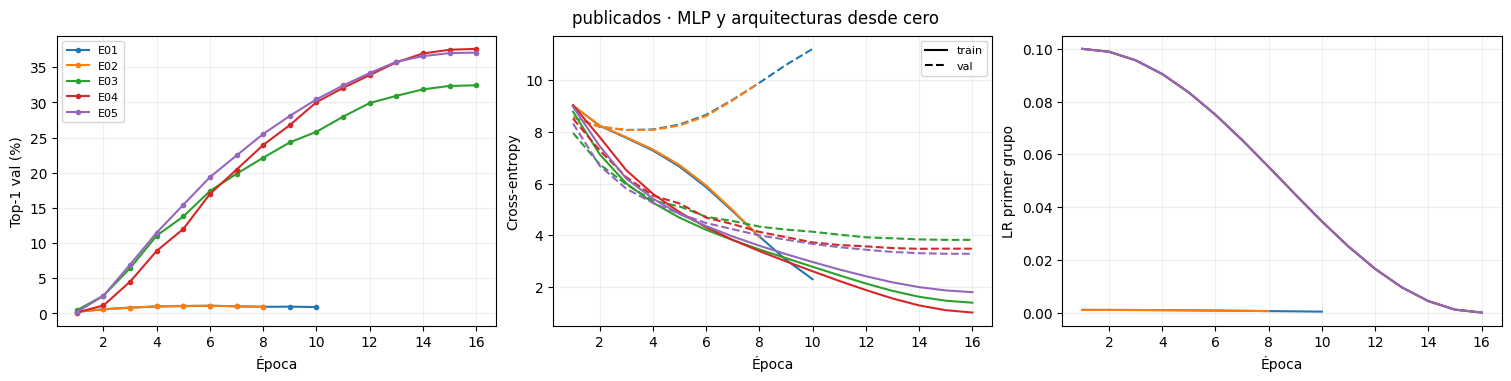

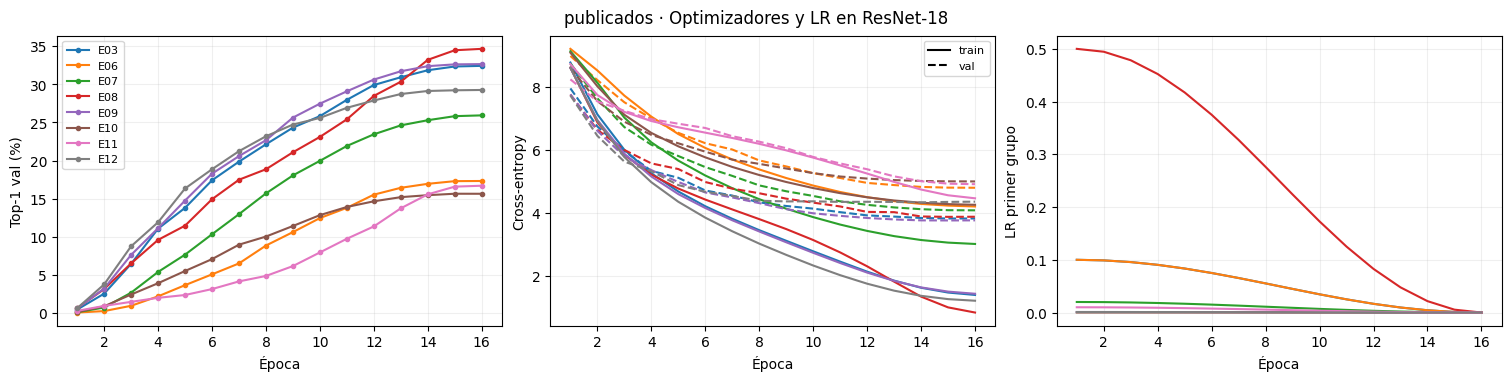

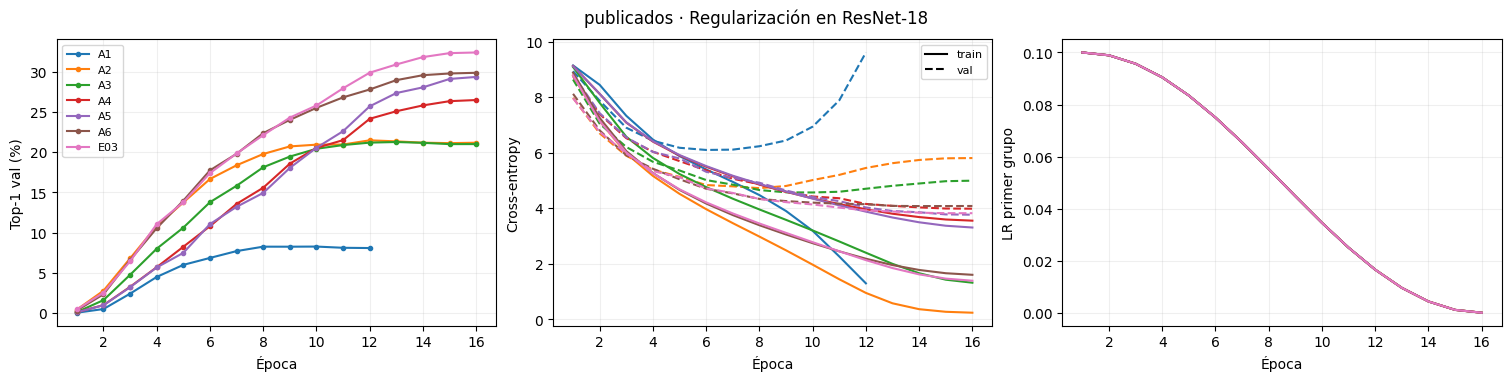

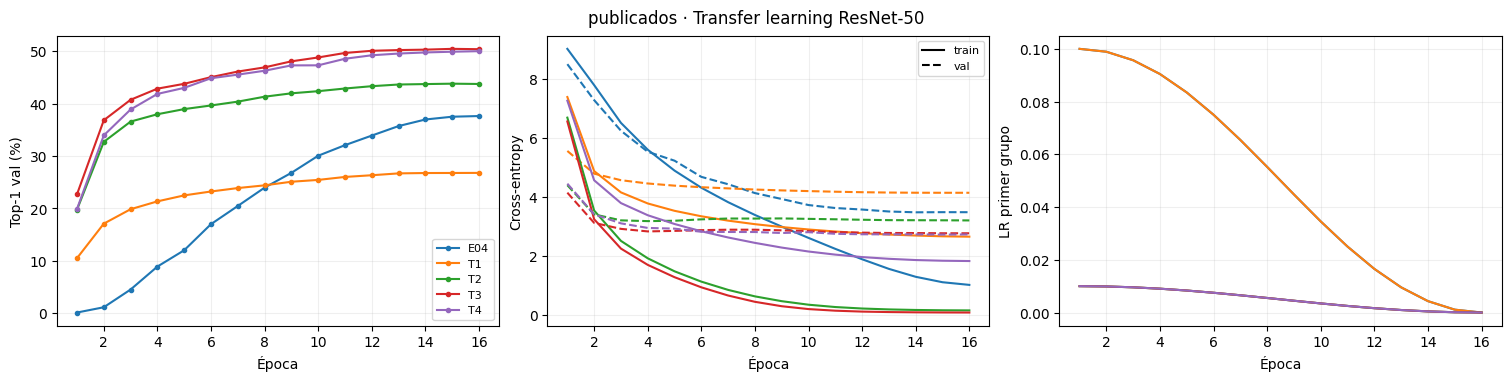

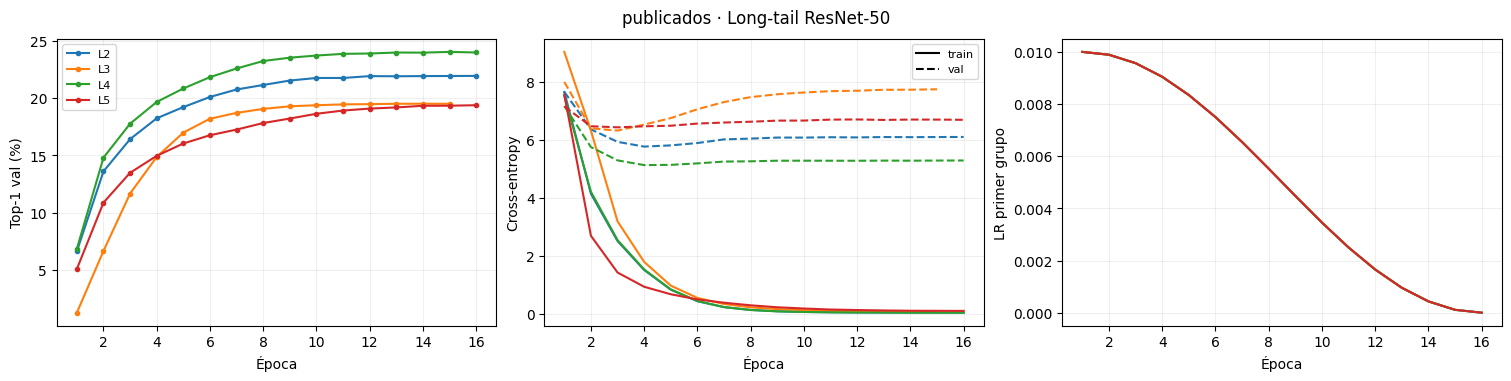

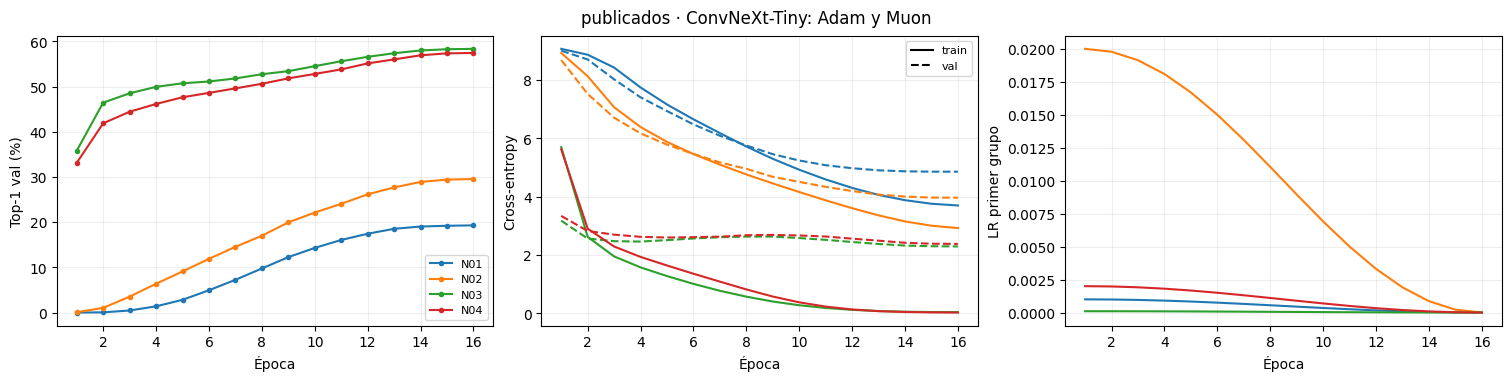

kingdom
Animalia    5388
Fungi        341
Plantae     4271
Name: Especies, dtype: int64

,Modelo,Parámetros,Pesos FP32 GB,GFLOPs
0,resnet18,16296912,0.065188,1.194607
1,resnet18,16306512,0.065226,1.194607
6,mlp,18647824,0.074591,0.037257
7,mlp,37522192,0.150089,0.075006
9,resnet50,43998032,0.175992,2.710110
10,efficientnet_b0,16817548,0.067270,0.277570
26,convnext_tiny,35510128,0.142041,2.924593


In [17]:
GROUPS = {
    "MLP y arquitecturas desde cero": ["E01", "E02", "E03", "E04", "E05"],
    "Optimizadores y LR en ResNet-18": ["E03", "E06", "E07", "E08", "E09", "E10", "E11", "E12"],
    "Regularización en ResNet-18": ["A1", "A2", "A3", "A4", "A5", "A6", "E03"],
    "Transfer learning ResNet-50": ["E04", "T1", "T2", "T3", "T4"],
    "Long-tail ResNet-50": ["L2", "L3", "L4", "L5"],
    "ConvNeXt-Tiny: Adam y Muon": ["N01", "N02", "N03", "N04"]}

def plot_histories(histories, label):
    from matplotlib.lines import Line2D
    destination = WORKSPACE / "figuras" / label
    destination.mkdir(parents=True, exist_ok=True)
    for title, ids in GROUPS.items():
        fig, axes = plt.subplots(1, 3, figsize=(15, 3.7), constrained_layout=True)
        for color_index, id_ in enumerate(ids):
            if id_ not in histories:
                continue
            h = pd.DataFrame(histories[id_])
            color = f"C{color_index}"
            axes[0].plot(h.epoca, h.val_top1 * 100, color=color, marker=".", label=id_)
            axes[1].plot(h.epoca, h.train_loss, color=color, label=id_ + " train")
            axes[1].plot(h.epoca, h.val_loss, color=color, linestyle="--", label=id_ + " val")
            axes[2].plot(h.epoca, h.lr, color=color, label=id_)
        for ax in axes:
            ax.set_xlabel("Época"); ax.grid(alpha=.2)
        axes[0].set_ylabel("Top-1 val (%)"); axes[1].set_ylabel("Cross-entropy")
        axes[2].set_ylabel("LR primer grupo"); axes[0].legend(fontsize=8)
        axes[1].legend(handles=[Line2D([0], [0], color="black", label="train"),
                               Line2D([0], [0], color="black", linestyle="--", label="val")], fontsize=8)
        fig.suptitle(label + " · " + title)
        fig.savefig(destination / (title.replace(" ", "_").replace(":", "") + ".png"), dpi=160)
        plt.show(); plt.close(fig)

def exploratory_analysis():
    if MODE != "train":
        # Datos tabulares de la taxonomía, no código descargado.
        species_path = download_file(PUBLIC_URL + "/references/n03_errors/especies.csv", REFERENCIAS / "especies.csv",
                                     "81a5ac1cbc9ab7aa273caf536e00aa636cad78f2dfb6552b64a3a626c173e760")
        species = pd.read_csv(species_path)
        display(species.groupby("kingdom").size().rename("Especies"))
        return species
    df = indice("train_mini")
    species = df.drop_duplicates("etiqueta").sort_values("etiqueta")
    fig, ax = plt.subplots(1, 3, figsize=(14, 3.5), constrained_layout=True)
    df.groupby("kingdom").size().plot.bar(ax=ax[0], title="Imágenes por reino")
    ax[1].hist(df.width / df.height, bins=60, range=(0, 4)); ax[1].set_title("Relación ancho/alto")
    support = long_tail()["n_por_clase"]
    ax[2].plot(np.sort(support)[::-1]); ax[2].set_title("Distribución long-tail (120474)")
    plt.show(); plt.close(fig)
    display(df[["width", "height"]].describe())
    return species

if MODE in ("audit", "train"):
    plot_histories(HISTORIAS, "publicados")
    if MODE == "train":
        NEW_HISTORIES = {cfg.id: json.loads((RESULTADOS / cfg.id / "historial.json").read_text())
                         for cfg in PLAN if (RESULTADOS / cfg.id / "historial.json").exists()}
        if NEW_HISTORIES:
            plot_histories(NEW_HISTORIES, "reentrenados")
    ESPECIES = exploratory_analysis()
    display(TABLA[["Modelo", "Parámetros", "Pesos FP32 GB", "GFLOPs"]].drop_duplicates())


In [18]:
def longtail_analysis():
    # Mismas frecuencias y asignación de especies que construir_long_tail; no requiere imágenes en audit.
    rng = np.random.default_rng(SEMILLA)
    order = rng.permutation(NUM_CLASES)
    rank = np.empty(NUM_CLASES, dtype=int)
    rank[order] = np.arange(NUM_CLASES)
    quotas = np.floor(50 * (1 / 50) ** (rank / (NUM_CLASES - 1)) + 1e-9).astype(int).clip(1, 50)
    assert quotas.sum() == 120474
    groups = np.where(quotas >= 20, 0, np.where(quotas >= 5, 1, 2))
    names = ("muchas (>=20)", "medias (5–19)", "pocas (<5)")
    rows = []
    for id_ in ("T3", "L2", "L3", "L4", "L5"):
        path = REFERENCIAS / id_ / "preds.npz"
        with np.load(path, allow_pickle=False) as data:
            y, pred = data["y"].astype(np.int64), data["top5"][:, 0].astype(np.int64)
        _, _, details = f1_desde_predicciones(torch.from_numpy(pred), torch.from_numpy(y))
        for group, name in enumerate(names):
            mask = groups == group
            rows.append({"ID": id_, "Grupo": name, "Especies": int(mask.sum()), "Train LT": int(quotas[mask].sum()),
                         "Macro-F1": float(details["f1"][mask].mean()), "Precisión": float(details["prec"][mask].mean()),
                         "Recall": float(details["rec"][mask].mean())})
    table = pd.DataFrame(rows)
    display(table)
    table.to_csv(WORKSPACE / "longtail_por_grupo.csv", index=False)
    return table

if MODE in ("audit", "train"):
    LONGTAIL_TABLA = longtail_analysis()


,ID,Grupo,Especies,Train LT,Macro-F1,Precisión,Recall
0,T3,muchas (>=20),2343,75550,0.504711,0.524634,0.504823
1,T3,medias (5–19),3543,36593,0.494519,0.511341,0.497686
2,T3,pocas (<5),4114,8331,0.505632,0.519746,0.510185
3,L2,muchas (>=20),2343,75550,0.283489,0.208303,0.492744
4,L2,medias (5–19),3543,36593,0.243995,0.279989,0.251058
5,L2,pocas (<5),4114,8331,0.054179,0.146816,0.036534
6,L3,muchas (>=20),2343,75550,0.251237,0.184102,0.443406
7,L3,medias (5–19),3543,36593,0.217068,0.262316,0.220632
8,L3,pocas (<5),4114,8331,0.045671,0.124908,0.030700
9,L4,muchas (>=20),2343,75550,0.336187,0.283959,0.442339


## 8. Errores, taxonomía y ejemplos visuales


count    10000.000000
mean         0.581245
std          0.220706
min          0.000000
25%          0.421053
50%          0.600000
75%          0.750000
max          1.000000
Name: F1, dtype: float64

,mean,count
kingdom,,
Animalia,0.586800,5388
Fungi,0.634402,341
Plantae,0.569995,4271


,Especie real,Predicción,Cantidad
0,Burnsius albescens,Burnsius communis,9
1,Nomophila noctuella,Nomophila nearctica,6
2,Callophrys rubi,Callophrys dumetorum,6
3,Pontia edusa,Pontia daplidice,6
4,Zygaena transalpina,Zygaena filipendulae,6
5,Hyla versicolor,Hyla chrysoscelis,6
6,Gallinula chloropus,Gallinula galeata,6
7,Conocephalum salebrosum,Conocephalum conicum,6
8,Scolopendra cingulata,Scolopendra polymorpha,5
9,Tetraopes femoratus,Tetraopes tetrophthalmus,5


kingdom exactitud 0.97297
phylum exactitud 0.95811
class exactitud 0.92116
order exactitud 0.80522
family exactitud 0.74136
genus exactitud 0.66501
Poblaciones: {'correctas_alta': 38203, 'correctas_baja': 333, 'incorrectas_alta': 10822, 'dificiles': 14}


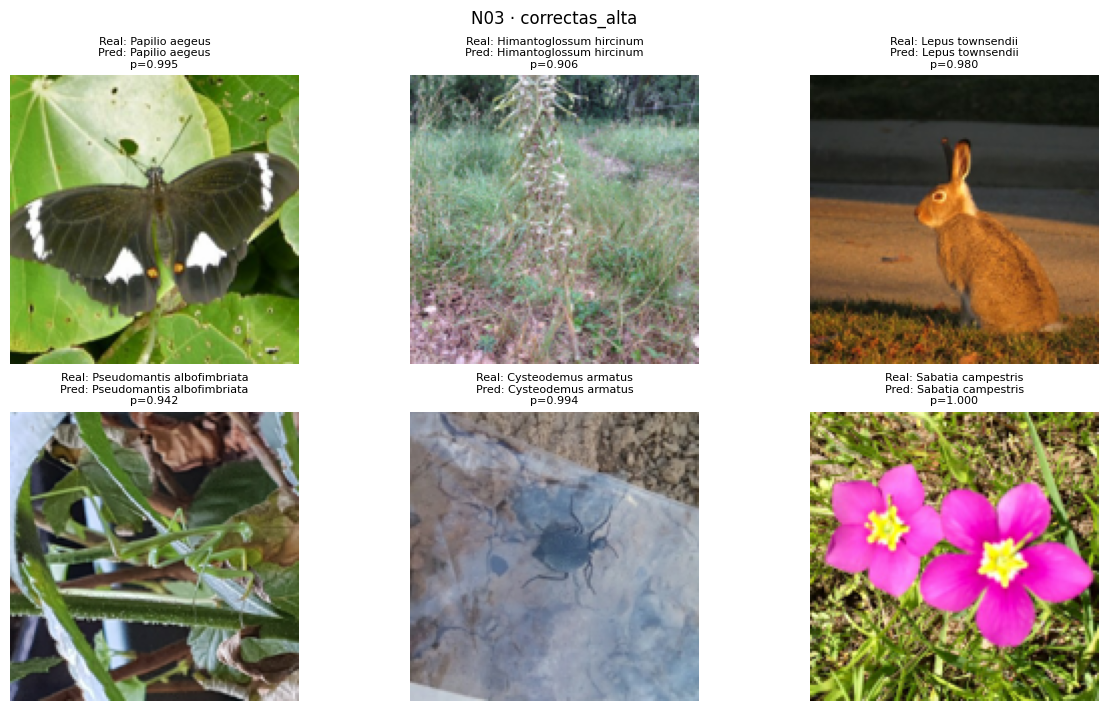

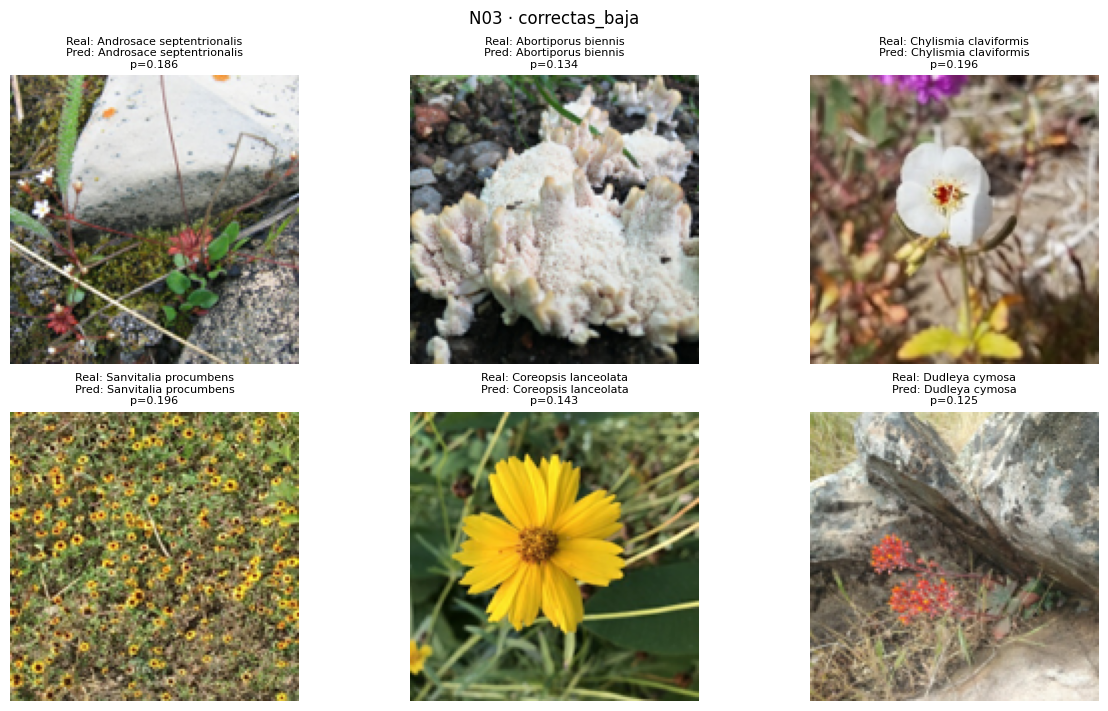

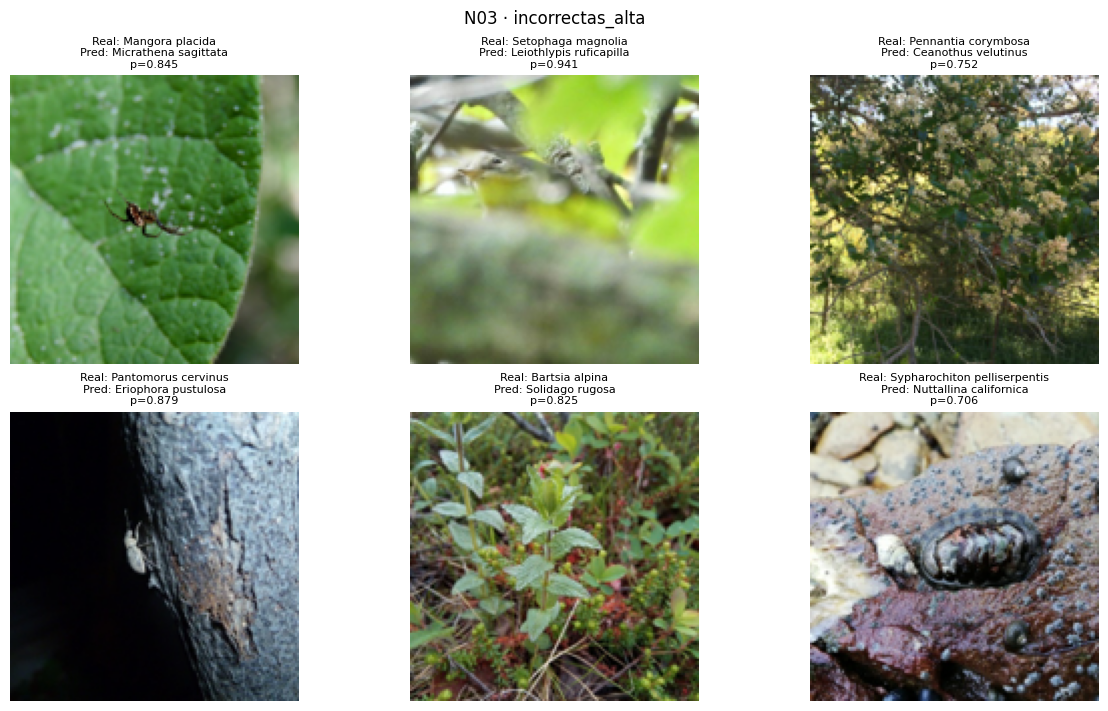

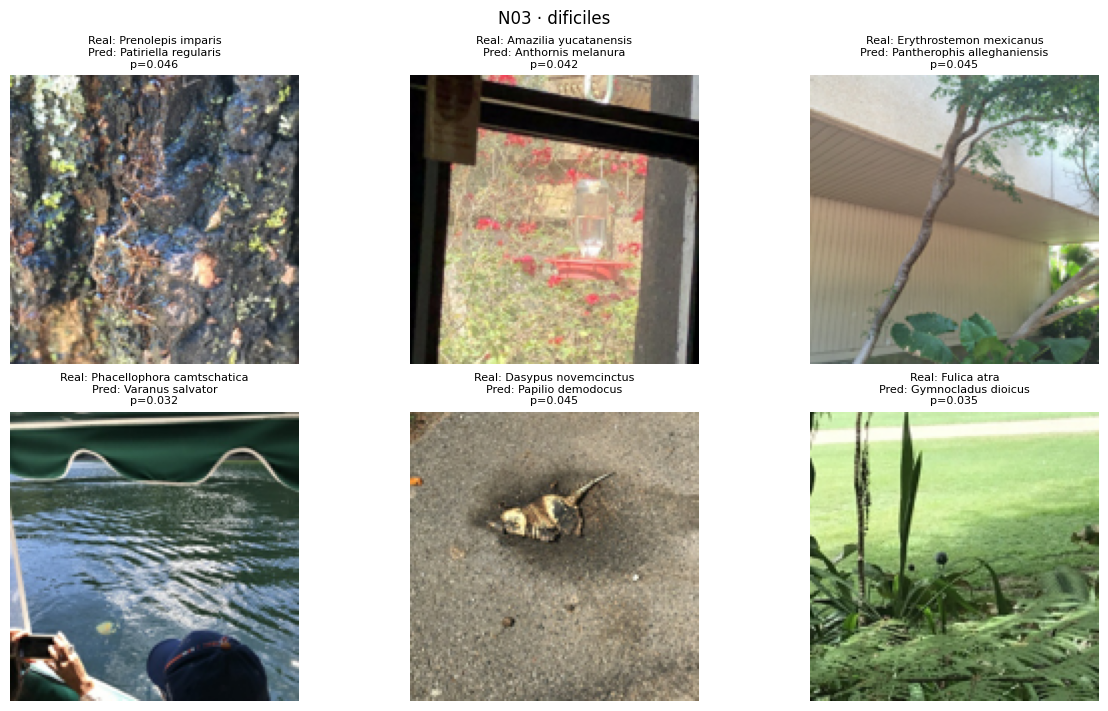

In [19]:
def analyze_predictions(directory, species):
    with np.load(directory / "preds.npz", allow_pickle=False) as data:
        y, top5, prob5 = data["y"].astype(np.int64), data["top5"].astype(np.int64), data["prob5"]
    pred = top5[:, 0]
    _, _, detail = f1_desde_predicciones(torch.from_numpy(pred), torch.from_numpy(y))
    names = species.set_index("etiqueta").reindex(np.arange(NUM_CLASES))
    per_species = names[["especie", "kingdom", "genus"]].copy()
    per_species["F1"] = detail["f1"].numpy()
    per_species["Recall"] = detail["rec"].numpy()
    per_species["Precisión"] = detail["prec"].numpy()
    per_species.to_csv(WORKSPACE / "metricas_por_especie.csv")
    display(per_species.F1.describe())
    display(per_species.groupby("kingdom")["F1"].agg(["mean", "count"]))
    errors = pred != y
    pairs, counts = np.unique(np.column_stack((y[errors], pred[errors])), axis=0, return_counts=True)
    worst = np.argsort(-counts, kind="stable")[:20]
    confusion = pd.DataFrame({"Especie real": names.especie.iloc[pairs[worst, 0]].to_numpy(),
                              "Predicción": names.especie.iloc[pairs[worst, 1]].to_numpy(), "Cantidad": counts[worst]})
    display(confusion)
    confusion.to_csv(WORKSPACE / "confusiones_top20.csv", index=False)
    for taxon in ("kingdom", "phylum", "class", "order", "family", "genus"):
        if taxon in names.columns:
            real = names[taxon].iloc[y].to_numpy(); predicted = names[taxon].iloc[pred].to_numpy()
            valid = pd.notna(real) & pd.notna(predicted)
            print(taxon, "exactitud", float(np.mean(real[valid] == predicted[valid])))
    correct = pred == y
    confidence = prob5[:, 0]
    confidence = confidence.astype(np.float64)  # Umbrales idénticos a las galerías archivadas.
    masks = {"correctas_alta": correct & (confidence > .9), "correctas_baja": correct & (confidence < .2),
             "incorrectas_alta": ~correct & (confidence > .7),
             "dificiles": ~(top5 == y[:, None]).any(1) & (confidence < .05)}
    rng = np.random.default_rng(0)
    chosen = {key: rng.choice(np.flatnonzero(mask), min(6, int(mask.sum())), replace=False)
              for key, mask in masks.items()}
    print("Poblaciones:", {key: int(mask.sum()) for key, mask in masks.items()})
    return names, y, pred, confidence, chosen

def image_galleries(directory, species, published=True):
    names, y, pred, confidence, chosen = analyze_predictions(directory, species)
    if published:
        manifest_path = download_file(PUBLIC_URL + "/references/n03_errors/manifest.json", REFERENCIAS / "images/manifest.json")
        manifest = json.loads(manifest_path.read_text())
        assert digest(directory / "preds.npz") == manifest["predictions_sha256"]
        lookup = {(s["criterion"], s["prediction_row"]): s for s in manifest["samples"]}
    else:
        val_ds = LotesMemmap("val")
    for criterion, rows in chosen.items():
        fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
        for axis in axes.flat:
            axis.axis("off")
        for axis, row in zip(axes.flat, rows):
            if published:
                sample = lookup[(criterion, int(row))]
                path = download_file(PUBLIC_URL + "/references/n03_errors/" + sample["image"],
                                     REFERENCIAS / "images" / sample["image"], sample["file_sha256"])
                with Image.open(path) as image:
                    pixels = np.array(image.convert("RGB"))
                assert hashlib.sha256(pixels.tobytes()).hexdigest() == sample["pixels_sha256"]
            else:
                xb, _ = val_ds[[row]]
                pixels = xb[0].numpy()[8:136, 8:136]
            axis.imshow(pixels)
            axis.set_title(f"Real: {names.especie.iloc[y[row]]}\nPred: {names.especie.iloc[pred[row]]}\np={confidence[row]:.3f}", fontsize=8)
        fig.suptitle(directory.name + " · " + criterion)
        destination = WORKSPACE / "figuras" / ("publicados" if published else "reentrenados")
        destination.mkdir(parents=True, exist_ok=True)
        fig.savefig(destination / (directory.name + "_" + criterion + ".png"), dpi=140)
        plt.show(); plt.close(fig)

if MODE in ("audit", "train"):
    image_galleries(REFERENCIAS / "N03", ESPECIES, published=True)
    if MODE == "train" and (RESULTADOS / "N03/resumen.json").exists():
        image_galleries(RESULTADOS / "N03", ESPECIES, published=False)
    atomic_json(WORKSPACE / "audit.json", {"commit": PUBLIC_COMMIT, "completed_references": len(TABLA),
                 "prediction_rows": len(TABLA) * 100000, "classes": NUM_CLASES,
                 "labels_sha256": LABELS_SHA256, "all_four_metrics_recomputed": True,
                 "new_training_executed": MODE == "train"})


## 9. Prueba sintética del código de entrenamiento


In [20]:
def smoke_checks():
    import tempfile
    from torch.utils.data import TensorDataset
    torch.set_num_threads(2)
    results = {}
    class IdentityAug(nn.Module):
        def forward(self, x, entrenamiento):
            return x
    class TinyModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.features = nn.Sequential(nn.Linear(9, 12), nn.LayerNorm(12), nn.GELU())
            self.classifier = nn.Linear(12, 7)
        def forward(self, x):
            return self.classifier(self.features(x))
    class BatchDataset(Dataset):
        def __init__(self):
            self.x = torch.arange(63).reshape(7, 9).float() / 63
            self.y = torch.arange(7)
        def __len__(self):
            return 7
        def __getitem__(self, batch):
            i = np.sort(np.asarray(batch))
            return self.x[i], self.y[i]
    ds = BatchDataset()
    for drop, expected in ((True, 6), (False, 7)):
        dl = cargador(ds, 3, True, 42, workers=0, drop_last=drop)
        assert sum(len(y) for _, y in dl) == expected
    results["historical_and_new_last_batch"] = True
    first_order = [y.tolist() for _, y in cargador(ds, 3, True, 42, workers=0)]
    assert first_order == [y.tolist() for _, y in cargador(ds, 3, True, 42, workers=0)]
    results["sampling_seed"] = True
    weights = np.ones(7)
    assert sum(len(y) for _, y in cargador(ds, 3, True, 42, weights, workers=0)) == 7
    results["weighted_sampling"] = True
    aum = IdentityAug()
    losses = []
    for optimizer in ("sgd", "sgdm", "adam", "adamw", "muon"):
        fijar_semillas(42)
        cfg = Config("smoke", optimizador=optimizer, lr=.01, weight_decay=5e-5)
        model = TinyModel()
        opt = crear_optimizador(cfg, model, [model.features])
        sched = torch.optim.lr_scheduler.LambdaLR(opt, programa_lr(6, 3))
        dl = cargador(ds, 3, True, 42, workers=0)
        before = state_hash(model)
        row = train_epoch(model, dl, aum, opt, sched, crear_perdida(cfg, np.ones(7), "cpu"), cfg, "cpu")
        assert row["train_samples"] == 7 and math.isfinite(row["train_loss"]) and state_hash(model) != before
        val = evaluar(model, cargador(ds, 3, False, workers=0), aum, "cpu", guardar=True, classes=7)
        assert val["_preds"]["top5"].shape == (7, 5)
        assert all(math.isfinite(val[k]) for k in ("loss", *METRICS))
        losses.append((optimizer, row["train_loss"]))
    results["five_optimizers_train_and_evaluate"] = losses
    for loss_name in ("ce", "ce_ponderada", "logit_ajustado"):
        cfg = Config("smoke", perdida=loss_name)
        z = torch.randn(7, 7, requires_grad=True)
        loss = crear_perdida(cfg, np.arange(1, 8), "cpu")(z, torch.arange(7))
        loss.backward()
        assert torch.isfinite(z.grad).all()
    results["three_losses_backward"] = True
    schedule = programa_lr(32, 2)
    assert schedule(0) == .5 and schedule(32) == 0 and schedule(16) > 0
    assert selected_epoch([{"epoca": 1, "val_top1": .5}, {"epoca": 2, "val_top1": .5005},
                           {"epoca": 3, "val_top1": .5015}], .001) == 3
    results["warmup_cosine_and_selection_delta"] = True
    x = torch.randint(0, 255, (3, 144, 144, 3), dtype=torch.uint8)
    for level in ("ninguno", "basico", "fuerte"):
        transformed = AumentoGPU(level)(x, entrenamiento=True)
        assert transformed.shape == (3, 3, 128, 128) and torch.isfinite(transformed).all()
    results["all_augmentation_levels"] = True
    # Reanudación: mismo siguiente paso, estado Adam/Muon, scheduler y RNG.
    with tempfile.TemporaryDirectory(dir=WORKSPACE) as tmp:
        tmp = Path(tmp)
        for optimizer in ("adam", "muon"):
            fijar_semillas(42)
            cfg = Config("smoke", optimizador=optimizer, lr=.01)
            model = TinyModel()
            opt = crear_optimizador(cfg, model, [model.features])
            scheduler = torch.optim.lr_scheduler.LambdaLR(opt, programa_lr(9, 3))
            def epoch_step(model, opt, scheduler, epoch):
                dl = cargador(ds, 3, True, 42 + epoch, workers=0)
                return train_epoch(model, dl, aum, opt, scheduler, crear_perdida(cfg, np.ones(7), "cpu"), cfg, "cpu")
            epoch_step(model, opt, scheduler, 0)
            path = tmp / (optimizer + ".pt")
            atomic_checkpoint(path, {"model": model.state_dict(), "opt": opt.state_dict(),
                                    "scheduler": scheduler.state_dict(), "rng": rng_state()})
            next_random = (random.random(), np.random.rand(), torch.rand(1).item())
            expected_loss = epoch_step(model, opt, scheduler, 1)["train_loss"]
            expected_hash, expected_lr = state_hash(model), scheduler.get_last_lr()
            saved = torch.load(path, weights_only=False)
            fresh = TinyModel()
            fresh.load_state_dict(saved["model"])
            fresh_opt = crear_optimizador(cfg, fresh, [fresh.features])
            fresh_sched = torch.optim.lr_scheduler.LambdaLR(fresh_opt, programa_lr(9, 3))
            fresh_opt.load_state_dict(saved["opt"]); fresh_sched.load_state_dict(saved["scheduler"])
            restore_rng(saved["rng"])
            assert next_random == (random.random(), np.random.rand(), torch.rand(1).item())
            actual_loss = epoch_step(fresh, fresh_opt, fresh_sched, 1)["train_loss"]
            assert actual_loss == expected_loss and state_hash(fresh) == expected_hash
            assert fresh_sched.get_last_lr() == expected_lr
        results["adam_muon_exact_cpu_resume"] = True
        # La única dependencia .py se crea arriba, se importa y se invoca.
        Image.fromarray(np.full((170, 200, 3), 127, np.uint8)).save(tmp / "test.jpg")
        mm = tmp / "smoke.u8"
        np.memmap(mm, mode="w+", dtype=np.uint8, shape=(1, 144, 144, 3)).flush()
        task = (str(tmp), str(mm), 1, 0, ["test.jpg"], 144)
        with ProcessPoolExecutor(max_workers=1) as executor:
            assert list(executor.map(resize_block, [task])) == [1]
        assert np.array_equal(np.memmap(mm, mode="r", dtype=np.uint8, shape=(1, 144, 144, 3)),
                              np.full((1, 144, 144, 3), 127, np.uint8))
        results["visible_py_import_and_multiprocessing"] = True
    atomic_json(WORKSPACE / "smoke.json", results)
    display(results)
    return results

if MODE == "smoke":
    SMOKE = smoke_checks()
